In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from time import time
import os
from dataclasses import replace
from RaTag.core.datatypes import Run, SetPmt, S2Areas
from RaTag.core.config import TimingConfig, IntegrationConfig, FitConfig
from RaTag.core.wfm2read_fast import wfm2read
from RaTag.core.paths import get_output_root
from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.thgem_tpc.drift_workflow import map_drift_physics
from RaTag.thgem_tpc.timing_workflow import map_time_windows, resolve_set_timing, map_timing_plots
from RaTag.thgem_tpc.recoil_workflow import map_recoil_integration, map_recoil_fits, map_recoil_plots



%matplotlib inline

# Initialize test run and set

In [4]:
# pattern = '/Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN32_EL25k/FieldScan_Gate0576_Anode1576/RUN32_20260702_Gate0576_Anode1576_P4'
# files = glob.glob(f"{pattern}*.wfm")
# filenames = [os.path.basename(f) for f in files]
# for i, file in enumerate(files):
#     os.rename(file, f"{pattern}_{i}Wfm.wfm")    

In [5]:
config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run43_analysis.yaml'

run = bootstrap_from_config(config_path)

Found 9 directories in RUN43_EL25kVcm
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0120_Anode1120 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0188_Anode1188 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0288_Anode1288 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0480_Anode1480 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0576_Anode1576 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0672_Anode1672 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0768_Anode1768 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0864_Anode1864 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0960_Anode1960 with 200 waveforms.
  → Bootstrapped 9 PMT Sets and 9 Alpha Sets. (Multi-Isotope: True)


In [5]:
set0 = run.sets[0]
print(set0)

SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN36_EL25kVcm/FieldScan_Gate0120_Anode1120
  filenames = <20 files, 19740 waveforms, FastFrame(987 frames/file)>
  multiiso = True
  ff = True
  nframes = 987
  gate = 120
  anode = 1120

  Missing:
    target_isotope, sampling_rate, drift_field, EL_field, red_drift_field, red_EL_field, speed_drift, time_drift, diffusion_coefficient, baseline_median, baseline_std, t_s1, t_s1_std, t_s2_start, t_s2_start_std, t_s2_end, t_s2_end_std, filtered_drift_time, n_areas_recoil, area_s2_mean, area_s2_sigma, area_s2_ci95, area_s2_fit_success, s2_background_bound


# Set drift properties

In [6]:
run = map_drift_physics(run, force=False)
set0 = run.sets[0]

  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0188_Anode1188'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0188_Anode1188'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0188_Anode1188'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0288_Anode1288'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0288_Anode1288'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0288_Anode1288'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0480_Anode1480'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0480_Anode1480'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0480_Anode1480'
  📂 Cache Hit: Loaded metada

In [7]:
set0

SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN43_EL25kVcm/FieldScan_Gate0120_Anode1120
  filenames = <200 files, 197400 waveforms, FastFrame(987 frames/file)>
  multiiso = True
  ff = True
  nframes = 987
  gate = 120
  anode = 1120
  drift_field = 250.0
  EL_field = 25000.0
  red_drift_field = 1.025
  red_EL_field = 102.513
  speed_drift = 1.329
  time_drift = 3.611
  t_s1 = -3.999
  t_s1_std = 0.015
  t_s2_start = -1.826
  t_s2_start_std = 2.053
  t_s2_end = 5.335
  t_s2_end_std = 2.834
  n_areas_recoil = 9575
  area_s2_mean = 10.582
  area_s2_sigma = 9.903
  area_s2_ci95 = 0.3
  area_s2_fit_success = True
  s2_background_bound = 0.0

  Missing:
    target_isotope, sampling_rate, diffusion_coefficient, baseline_median, baseline_std, filtered_drift_time

In [8]:
for s in run.sets:
    print(s.speed_drift, s.time_drift)

1.329 3.611
1.482 3.238
1.652 2.906
1.868 2.57
1.943 2.47
2.005 2.394
2.057 2.334
2.101 2.285
2.138 2.245


# Test new timing_workflow

## Debug for Individual sets

In [15]:
from RaTag.plotting import plot_waveform, plot_frames, plot_random_frames
from RaTag.core.dataIO import load_wfm
from RaTag.io.file_ops import iter_waveforms, iter_frames
from RaTag.waveform.preprocessing import subtract_pedestal, moving_average, threshold_clip
from RaTag.thgem_tpc.timing_workflow import find_s1, find_s2

In [12]:
set8 = run.sets[6]
set8t = resolve_set_timing(set8, max_frames=1200, config=TimingConfig(), force=False)

  📂 Cache Hit: Loaded metadata for 't_s2_end in FieldScan_Gate0384_Anode1284'


In [10]:
out_s1 = []
for wf in iter_waveforms(set8, max_files=3):
    t_s1 = find_s1(wf, config=TimingConfig())
    out_s1.append(t_s1)
out_s1 = np.concatenate(out_s1)

In [11]:
set8 = run.sets[6]
fileidx = 0
frameidx = 0
wf = load_wfm(set8.source_dir / set8.filenames[fileidx])

(<Figure size 1000x1600 with 4 Axes>,
 array([<Axes: title={'center': 'Waveform, File 35, frame 144 of 493'}, xlabel='Time (µs)', ylabel='Signal (mV)'>,
        <Axes: title={'center': 'Waveform, File 16, frame 8 of 493'}, xlabel='Time (µs)', ylabel='Signal (mV)'>,
        <Axes: title={'center': 'Waveform, File 10, frame 303 of 493'}, xlabel='Time (µs)', ylabel='Signal (mV)'>,
        <Axes: title={'center': 'Waveform, File 35, frame 478 of 493'}, xlabel='Time (µs)', ylabel='Signal (mV)'>],
       dtype=object))

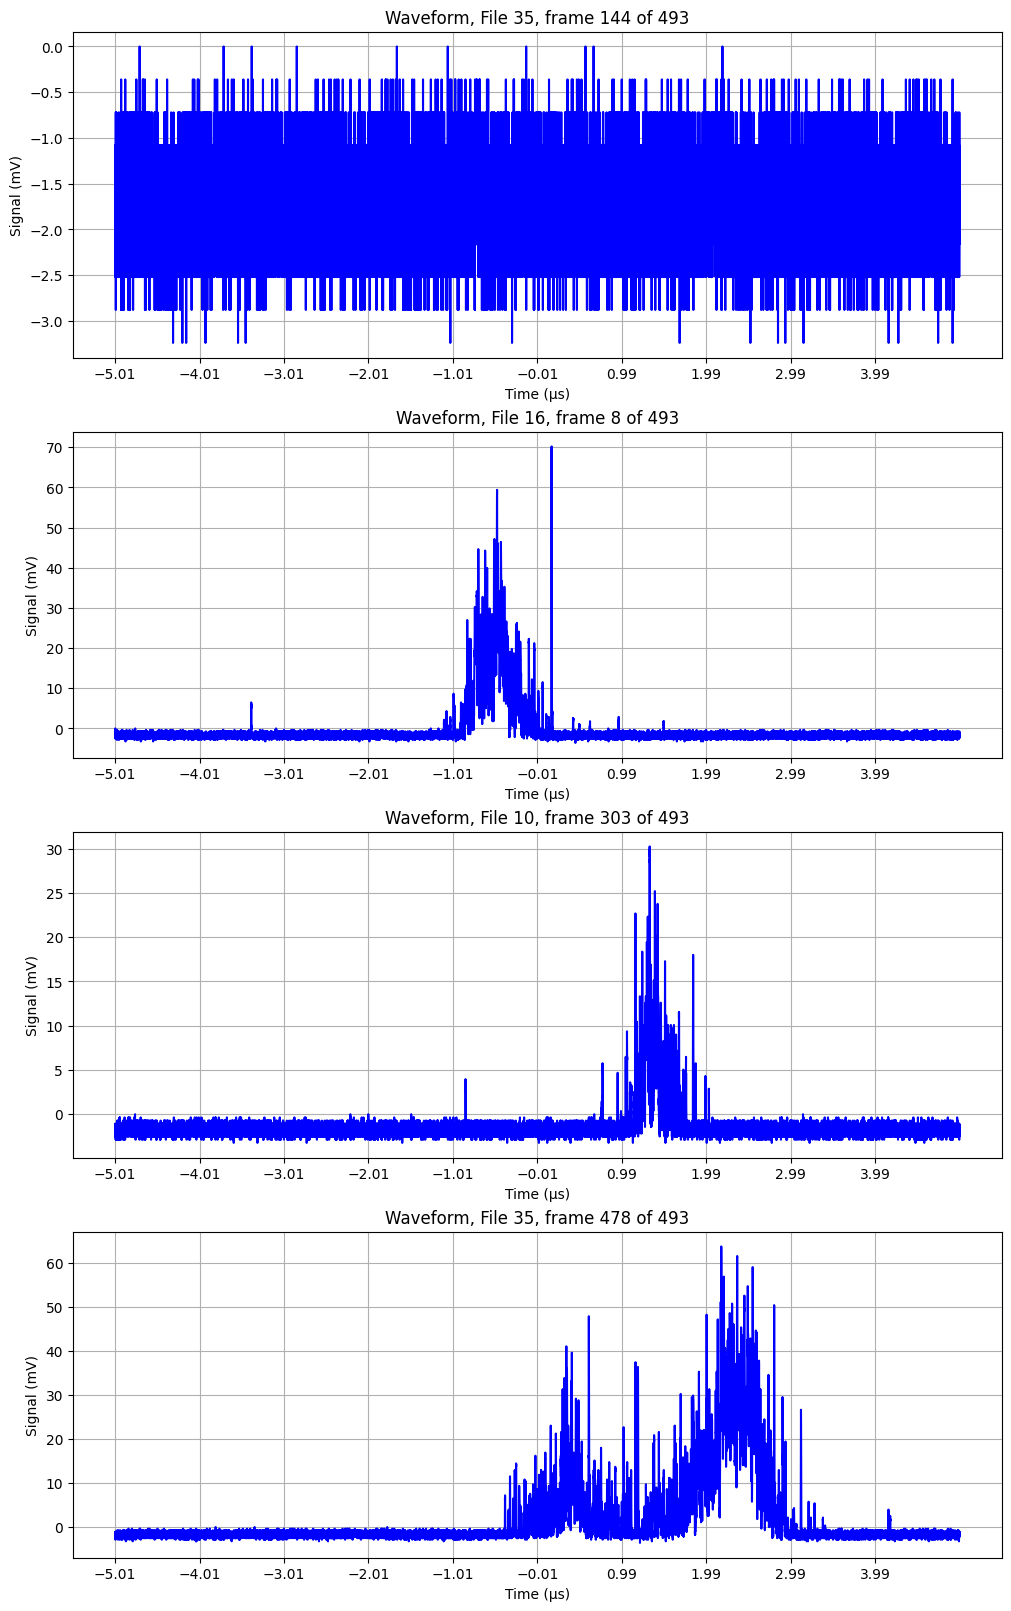

In [18]:
plot_random_frames(set8, n_frames=4, )

In [13]:
set8t.filenames[19]

'RUN32_20260702_Gate0384_Anode1384_P6_28Wfm.wfm'

## Full run

In [42]:
runt = map_time_windows(run, max_frames=1200, config=TimingConfig(), force=False)

  ✓ FieldScan_Gate0120_Anode1020: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0144_Anode1044: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0188_Anode1088: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0216_Anode1116: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0252_Anode1152: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0288_Anode1188: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0384_Anode1284: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0480_Anode1380: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0576_Anode1476: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0672_Anode1572: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate0768_Anode1668: Computed 't_s2_end' and stored metadata


## Plot timing results

In [43]:
runt = map_timing_plots(runt, force=True)


GENERATING TIMING PLOTS: RUN_33
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN33_EL22p5k/plots/timing_qa/RUN_33_histograms.png
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN33_EL22p5k/plots/timing_qa/RUN_33_validation.png
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN33_EL22p5k/plots/timing_qa/RUN_33_timing_vs_field.png


In [46]:
set11t = runt.sets[11]
set11t

SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN31_EL20k/FieldScan_Gate0576_Anode1376
  filenames = <40 files, 19720 waveforms, FastFrame(493 frames/file)>
  multiiso = False
  ff = True
  nframes = 493
  gate = 576
  anode = 1376
  drift_field = 1200.0
  EL_field = 20000.0
  red_drift_field = 4.921
  red_EL_field = 82.011
  speed_drift = 1.943
  time_drift = 2.47
  t_s1 = -2.513
  t_s1_std = 0.754
  t_s2_start = -0.427
  t_s2_start_std = 0.187
  t_s2_end = 2.228
  t_s2_end_std = 1.203

  Missing:
    sampling_rate, diffusion_coefficient, baseline_median, baseline_std, n_areas_recoil, area_s2_mean, area_s2_sigma, area_s2_ci95, area_s2_fit_success

# Integration pipeline

In [44]:
integ_dict = {
    'n_sigma_start': 2,
    'n_sigma_end': 2,
    'n_pedestal': 200,
    'ma_window': 9,
    'bs_threshold': 0.03,
    'dt': 2e-4
}

integ_config = IntegrationConfig(**integ_dict)

In [ ]:
runi = map_recoil_integration(runt, max_frames=None, config=integ_config, force=False)


INTEGRATING S2 RECOILS: RUN_33
  Integrating set FieldScan_Gate0120_Anode1020 with Static Window: [-2.06, 7.05] µs
  🔹 Processed 40 waveforms for S2 area integration.
  ✓ FieldScan_Gate0120_Anode1020: Computed 'n_areas_recoil' and stored metadata
  Integrating set FieldScan_Gate0144_Anode1044 with Static Window: [-2.26, 1.91] µs
  🔹 Processed 40 waveforms for S2 area integration.
  ✓ FieldScan_Gate0144_Anode1044: Computed 'n_areas_recoil' and stored metadata
  Integrating set FieldScan_Gate0188_Anode1088 with Static Window: [-2.42, 3.14] µs
  🔹 Processed 40 waveforms for S2 area integration.
  ✓ FieldScan_Gate0188_Anode1088: Computed 'n_areas_recoil' and stored metadata
  Integrating set FieldScan_Gate0216_Anode1116 with Static Window: [-2.51, 1.02] µs
  🔹 Processed 80 waveforms for S2 area integration.
  ✓ FieldScan_Gate0216_Anode1116: Computed 'n_areas_recoil' and stored metadata
  Integrating set FieldScan_Gate0252_Anode1152 with Static Window: [-2.75, 2.45] µs
  🔹 Processed 40 wav

## Fits s2 area histograms

### Single set debug

In [18]:
from RaTag.core.paths import get_output_root
from RaTag.el_tpc.fit_s2_area import v_crystalball_right
from RaTag.io.file_ops import load_fit_result, load_s2areas
from RaTag.plotting import plot_s2areas_summary

In [30]:
set8i.source_dir.name

'FieldScan_Gate0576_Anode1576'

In [35]:
counts, bins = np.histogram(s2_areas.areas, bins=100, range=(3, 50))
cbins = 0.5 * (bins[1:] + bins[:-1])
n_smooth1 = np.convolve(counts, np.ones(1)/1, mode='same')
n_smooth2 = np.convolve(counts, np.ones(2)/2, mode='same')
n_smooth3 = np.convolve(counts, np.ones(3)/3, mode='same')


In [19]:
set8i = runi.sets[8]
s2_areas = load_s2areas(set8i)
fit_path = get_output_root(set8i.source_dir.parent) / "fits" / f"{set8i.source_dir.name}_s2_areas_hist_fit.json"
fit_model = load_fit_result(fit_path, funcdefs={'v_crystalball_right': v_crystalball_right})

## Full run

In [46]:
fit_config = FitConfig(
    bin_cuts=(1, 52),
    nbins=100,
    bg_threshold=0.5,
    bg_cutoff=5.0,
    n_sigma=2.5)

runif = map_recoil_fits(runi, config=fit_config, force=True)

map_recoil_plots(runif, config=fit_config, force=True);


FITTING S2 AREA DISTRIBUTIONS: RUN_33
  Fit success: True, χ²/DOF: 254.97
  ✓ Fit: μ=8.330 ± 0.299 mV·µs
  ✓ FieldScan_Gate0120_Anode1020: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 419.58
  ✓ Fit: μ=6.595 ± 0.289 mV·µs
  ✓ FieldScan_Gate0144_Anode1044: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 152.64
  ✓ Fit: μ=8.685 ± 0.300 mV·µs


/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:17: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


  ✓ FieldScan_Gate0188_Anode1088: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 239.38
  ✓ Fit: μ=7.384 ± 0.477 mV·µs
  ✓ FieldScan_Gate0216_Anode1116: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 139.67
  ✓ Fit: μ=9.201 ± 0.312 mV·µs
  ✓ FieldScan_Gate0252_Anode1152: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 513.23
  ✓ Fit: μ=10.798 ± 0.289 mV·µs
  ✓ FieldScan_Gate0288_Anode1188: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 524.35
  ✓ Fit: μ=10.328 ± 0.289 mV·µs
  ✓ FieldScan_Gate0384_Anode1284: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 362.27
  ✓ Fit: μ=9.746 ± 0.289 mV·µs


/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:17: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m
/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:17: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m
/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:17: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


  ✓ FieldScan_Gate0480_Anode1380: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 718.69
  ✓ Fit: μ=10.156 ± 0.289 mV·µs
  ✓ FieldScan_Gate0576_Anode1476: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 346.19
  ✓ Fit: μ=11.607 ± 0.316 mV·µs
  ✓ FieldScan_Gate0672_Anode1572: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 665.75
  ✓ Fit: μ=10.602 ± 0.289 mV·µs


/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:17: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m
/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:17: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


  ✓ FieldScan_Gate0768_Anode1668: Computed 'area_s2_fit_success' and stored metadata

GENERATING RECOIL S2 AREAS QA PLOTS: RUN_33
  Loaded fit model for FieldScan_Gate0120_Anode1020 with lower_bound=2.2750000000000004
Set FieldScan_Gate0120_Anode1020: lower_bound=2.2750000000000004
  Loaded fit model for FieldScan_Gate0144_Anode1044 with lower_bound=2.785
Set FieldScan_Gate0144_Anode1044: lower_bound=2.785
  Loaded fit model for FieldScan_Gate0188_Anode1088 with lower_bound=2.2750000000000004
Set FieldScan_Gate0188_Anode1088: lower_bound=2.2750000000000004
  Loaded fit model for FieldScan_Gate0216_Anode1116 with lower_bound=4.825
Set FieldScan_Gate0216_Anode1116: lower_bound=4.825
  Loaded fit model for FieldScan_Gate0252_Anode1152 with lower_bound=3.295
Set FieldScan_Gate0252_Anode1152: lower_bound=3.295
  Loaded fit model for FieldScan_Gate0288_Anode1188 with lower_bound=2.785
Set FieldScan_Gate0288_Anode1188: lower_bound=2.785
  Loaded fit model for FieldScan_Gate0384_Anode1284 with

# New coincidence workflow

In [15]:
from RaTag.thgem_tpc.coincidence_workflow import (map_coincidence_extraction, resolve_set_coincidence,
                                                   map_filter_drift_time, resolve_drift_time_filter)
from RaTag.thgem_tpc.recoil_workflow import resolve_set_s2_fit
from RaTag.el_tpc.fit_s2_area import fit_s2_crystalball
from RaTag.io.file_ops import (load_fit_result, load_s2areas,
                                load_s2areas_from_path, load_s1areas,
                                  load_npz_arrays,load_waveform_by_uid,
                                  extract_single_frame)
from RaTag.thgem_tpc.multiiso_workflow import map_multiiso_separation, resolve_multiiso_separation
from RaTag.alphas.alphas_workflow import resolve_alpha_energies, map_alpha_events

### Single set debug

In [6]:
set8 = run.sets[6]
set8c = resolve_set_coincidence(set8, max_frames=None, config=TimingConfig(), force=False)

  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0480_Anode1280'


In [13]:
aset8 = run.alpha_sets[6]
aset8 = resolve_alpha_energies(aset8, force=False)

  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0480_Anode1280'


  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/s2_areas/FieldScan_Gate0480_Anode1280_s2_areas.npz


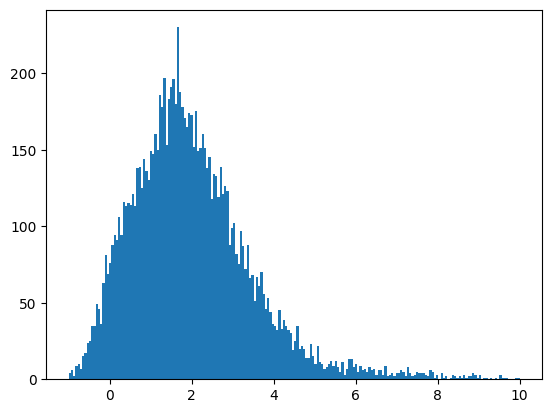

In [7]:
areas = load_s2areas(set8c)
plt.hist(areas.areas, bins=200, range=(-1, 10));

In [8]:
resolve_set_s2_fit(set8c, config=FitConfig(), force=True)

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/s2_areas/FieldScan_Gate0480_Anode1280_s2_areas.npz
  Fit success: True, χ²/DOF: 0.18
  ✓ Fit: μ=10.519 ± 0.464 mV·µs
  ✓ FieldScan_Gate0480_Anode1280: Computed 'area_s2_fit_success' and stored metadata


SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN35_EL20kVcm/FieldScan_Gate0480_Anode1280
  filenames = <20 files, 19740 waveforms, FastFrame(987 frames/file)>
  multiiso = True
  ff = True
  nframes = 987
  gate = 480
  anode = 1280
  drift_field = 1000.0
  EL_field = 20000.0
  red_drift_field = 4.101
  red_EL_field = 82.011
  speed_drift = 1.868
  time_drift = 2.57
  t_s1_std = 0.0
  t_s2_start = -2.485
  t_s2_start_std = 0.885
  t_s2_end = 0.613
  t_s2_end_std = 1.328
  n_areas_recoil = 121
  area_s2_mean = 10.519012012015235
  area_s2_sigma = 0.9488279295575422
  area_s2_ci95 = 0.46379006151631835
  area_s2_fit_success = True
  s2_background_bound = 9.75

  Missing:
    target_isotope, sampling_rate, diffusion_coefficient, baseline_median, baseline_std, t_s1, filtered_drift_time

In [14]:
set8mi = resolve_multiiso_separation(set8c, aset8, force=True)

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/s2_areas/FieldScan_Gate0480_Anode1280_s2_areas.npz
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/alpha_energies/FieldScan_Gate0480_Anode1280_alpha_energies.npz
    ✓ Separated Th228: 19815 events
    ✓ Separated Ra224: 17888 events
    ✓ Separated Bi212: 11137 events
    ✓ Separated Rn220: 10910 events
    ✓ Separated Po216: 12327 events
    ✓ Separated Po212: 7377 events


{'energies': array([5.0183682 , 4.41873908, 7.24097065, ..., 5.00638748, 5.54361432,
        7.32509536]),
 'uids': array([  64,   65,   66, ..., 2264, 2265, 2266])}

## Full run

In [24]:
run = map_coincidence_extraction(run, config=TimingConfig(), force = False)


EXTRACTING COINCIDENCE DATA: RUN_36
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz
  Iterating FieldScan_Gate0120_Anode1120: 20/20 (100.0%) | ETA: 00:00   
  FieldScan_Gate0120_Anode1120: 9793/19740 events (49.6%)
  ✓ FieldScan_Gate0120_Anode1120: Computed 'n_areas_recoil' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/s2_areas/FieldScan_Gate0156_Anode1156_s2_areas.npz
  Iterating FieldScan_Gate0156_Anode1156: 20/20 (100.0%) | ETA: 00:00   
  FieldScan_Gate0156_Anode1156: 10068/19740 events (51.0%)
  ✓ FieldScan_Gate0156_Anode1156: Computed 'n_areas_recoil' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/s2_areas/FieldScan_Gate0188_Anode1188_s2_areas.npz
  Iterating FieldScan_Gate0188_Anode1188: 20/20 (100.0%) | ETA: 00:00   
  FieldScan_Gate0188_Anode1188: 10249/19740 events (51.9

In [66]:
# map_filter_drift_time(run, dt_tolerance=0.6, force=True)


FILTERING BY DRIFT TIME (Blob Isolation): RUN_36
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/timing/FieldScan_Gate0120_Anode1120_timing.npz
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz
  [Skipping] FieldScan_Gate0120_Anode1120: Missing npz files.
  ✓ FieldScan_Gate0120_Anode1120: Computed 'filtered_drift_time' and stored metadata
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/timing/FieldScan_Gate0156_Anode1156_timing.npz
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/s2_areas/FieldScan_Gate0156_Anode1156_s2_areas.npz
  [Skipping] FieldScan_Gate0156_Anode1156: Missing npz files.
  ✓ FieldScan_Gate0156_Anode1156: Computed 'filtered_drift_time' and stored metadata
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/timing/FieldScan_Gate0188_Anode1188_

Run state:
  root_directory = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN36_EL25kVcm
  run_id = RUN_36
  el_field = 25000.0
  multiiso = True
  target_isotope = multi
  pressure = 1.0
  temperature = 297.0
  sampling_rate = 5.0e9
  el_gap = 0.04
  drift_gap = 0.48
  sets = <9 SetPmt objects>
  alpha_sets = <9 SetAlpha objects>
  gas_density = 2.4387106114612523e+19
  width_s2 = 1.1
  t_s1 = 0.0
  recoil_energy = 96.8
  W_value = 22.0
  E_gamma_xray = 12300.0

  Missing:
    g_S2, alpha_calibration, isotope_ranges

In [25]:
map_timing_plots(run, force=True)


GENERATING TIMING PLOTS: RUN_36
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/timing/FieldScan_Gate0120_Anode1120_timing.npz
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/timing/FieldScan_Gate0156_Anode1156_timing.npz
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/timing/FieldScan_Gate0188_Anode1188_timing.npz
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/timing/FieldScan_Gate0216_Anode1216_timing.npz
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/timing/FieldScan_Gate0288_Anode1288_timing.npz
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/timing/FieldScan_Gate0384_Anode1384_timing.npz
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/timing/FieldScan_Gate0480_Anode1480_timing.npz
  Loading timing arrays from: /Volumes/KINGSTON/Ra

Run state:
  root_directory = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN36_EL25kVcm
  run_id = RUN_36
  el_field = 25000.0
  multiiso = True
  target_isotope = multi
  pressure = 1.0
  temperature = 297.0
  sampling_rate = 5.0e9
  el_gap = 0.04
  drift_gap = 0.48
  sets = <9 SetPmt objects>
  alpha_sets = <9 SetAlpha objects>
  gas_density = 2.4387106114612523e+19
  width_s2 = 1.1
  t_s1 = 0.0
  recoil_energy = 96.8
  W_value = 22.0
  E_gamma_xray = 12300.0

  Missing:
    g_S2, alpha_calibration, isotope_ranges

In [29]:
from RaTag.core.config import FitConfig
FitConfig()

FitConfig(bin_cuts=(0, 50), nbins=100, bg_threshold=0.3, bg_cutoff=2.0, n_sigma=2.5)

In [27]:
run = map_recoil_fits(run, config=FitConfig(bin_cuts=(-1, 10), smooth=3), force=True)
run = map_recoil_plots(run, config=FitConfig(bin_cuts=(-1, 10)), force=True)


FITTING S2 AREA DISTRIBUTIONS: RUN_36
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz
  Fit success: True, χ²/DOF: 2.17
  ✓ Fit: μ=4.624 ± 0.078 mV·µs
  ✓ FieldScan_Gate0120_Anode1120: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/s2_areas/FieldScan_Gate0156_Anode1156_s2_areas.npz
  Fit success: True, χ²/DOF: 76.78
  ✓ Fit: μ=1.978 ± 0.067 mV·µs
  ✓ FieldScan_Gate0156_Anode1156: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/s2_areas/FieldScan_Gate0188_Anode1188_s2_areas.npz
  Fit success: True, χ²/DOF: 61.75
  ✓ Fit: μ=1.614 ± 0.065 mV·µs
  ✓ FieldScan_Gate0188_Anode1188: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/s2_areas/Fie

In [16]:
run = map_alpha_events(run, force=False)


RECONSTRUCTING ALPHA ENERGIES: RUN_35
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0120_Anode0920'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0156_Anode0956'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0188_Anode0988'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0216_Anode1016'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0288_Anode1088'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0384_Anode1184'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0480_Anode1280'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0576_Anode1376'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0672_Anode1472'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0768_Anode1568'


In [17]:

run = map_multiiso_separation(run)


SEPARATING MULTI-ISOTOPE SETS: RUN_35

  Mapping FieldScan_Gate0120_Anode0920...
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/s2_areas/FieldScan_Gate0120_Anode0920_s2_areas.npz
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/alpha_energies/FieldScan_Gate0120_Anode0920_alpha_energies.npz
    ✓ Separated Th228: 174072 events
    ✓ Separated Ra224: 162399 events
    ✓ Separated Bi212: 88826 events
    ✓ Separated Rn220: 106398 events
    ✓ Separated Po216: 111073 events
    ✓ Separated Po212: 71290 events

  Mapping FieldScan_Gate0156_Anode0956...
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/s2_areas/FieldScan_Gate0156_Anode0956_s2_areas.npz
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/alpha_energies/FieldScan_Gate0156_Anode0956_alpha_energies.npz
    ✓ Separated Th228: 11554 events
    ✓ Separated Ra224: 10416 events

In [32]:
run.sets[2]

SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN36_EL25kVcm/FieldScan_Gate0188_Anode1188
  filenames = <20 files, 19740 waveforms, FastFrame(987 frames/file)>
  multiiso = True
  ff = True
  nframes = 987
  gate = 188
  anode = 1188
  drift_field = 391.667
  EL_field = 25000.0
  red_drift_field = 1.606
  red_EL_field = 102.513
  speed_drift = 1.482
  time_drift = 3.238
  t_s1_std = 0.0
  t_s2_start = -2.495
  t_s2_start_std = 0.044
  t_s2_end = 5.36
  t_s2_end_std = 1.107
  n_areas_recoil = 10249
  area_s2_mean = 1.6141660414506749
  area_s2_sigma = 0.9438791357482105
  area_s2_ci95 = 0.06505041160037947
  area_s2_fit_success = True
  s2_background_bound = 0.595

  Missing:
    target_isotope, sampling_rate, diffusion_coefficient, baseline_median, baseline_std, t_s1, filtered_drift_time

## Filter by S1

In [12]:
for s in run.sets:
    areas = load_s2areas(s)
    print(len(areas.areas))

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz
4285
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0144_Anode1144_s2_areas.npz
4512
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0188_Anode1188_s2_areas.npz
5054
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0216_Anode1216_s2_areas.npz
5384
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0252_Anode1252_s2_areas.npz
5771
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0288_Anode1288_s2_areas.npz
6158
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0384_Anode1384_s2_areas.npz
7366
  Loading s2_areas arrays f

In [27]:
from RaTag.core.paths import get_output_root

path_areas_root = get_output_root(run.root_directory) / "s2_areas_coincidence"

for s in run.sets:
    path_file = f"{path_areas_root / s.name}_s2_areas.npz"
    areas_coincidence = load_s2areas_from_path(path_file)

    areas = load_s2areas(s)
    print(len(areas.areas) / len(areas_coincidence.areas))

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz
3.1882440476190474
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0144_Anode1144_s2_areas.npz
3.109579600275672
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0188_Anode1188_s2_areas.npz
3.3760855043420173
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0216_Anode1216_s2_areas.npz
3.553795379537954
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0252_Anode1252_s2_areas.npz
3.7768324607329844
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas/FieldScan_Gate0288_Anode1288_s2_areas.npz
4.119063545150501
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2

In [9]:
from RaTag.plotting import (plot_s1_area_distribution, plot_s2_area_distribution,
                             plot_s1_vs_s2_2d, plot_set_s1_vs_drift_time, plot_s2areas_summary)
from RaTag.el_tpc.fit_s2_area import optimize_s1_cut
import math

In [10]:
path = Path('/Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/s2_areas')
files = list(path.glob('*s2_areas.npz'))


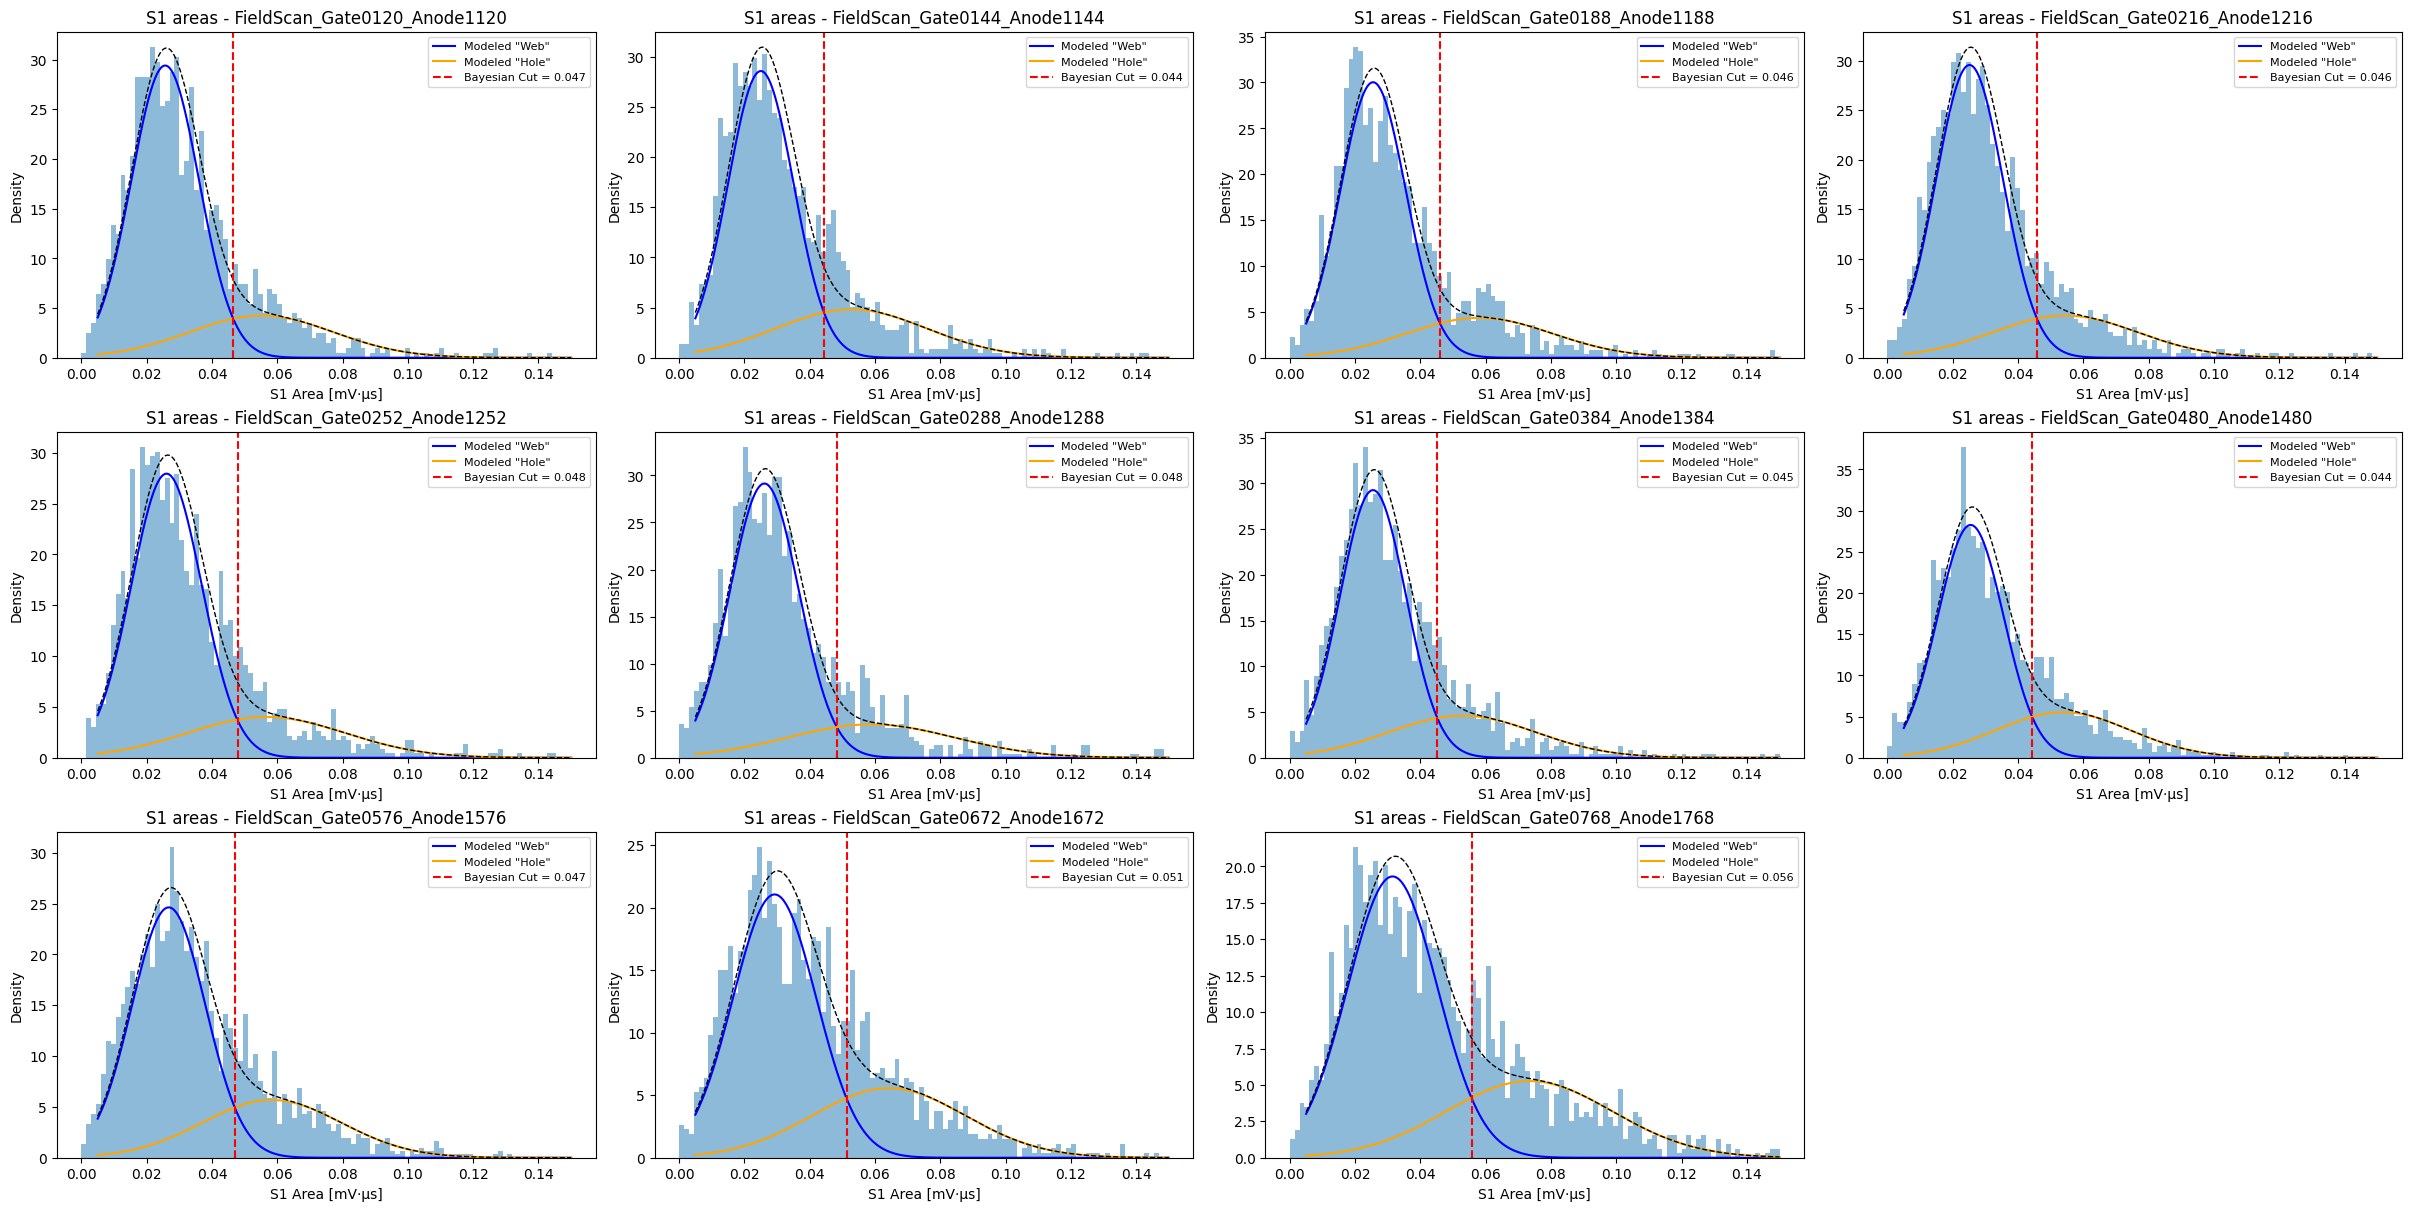

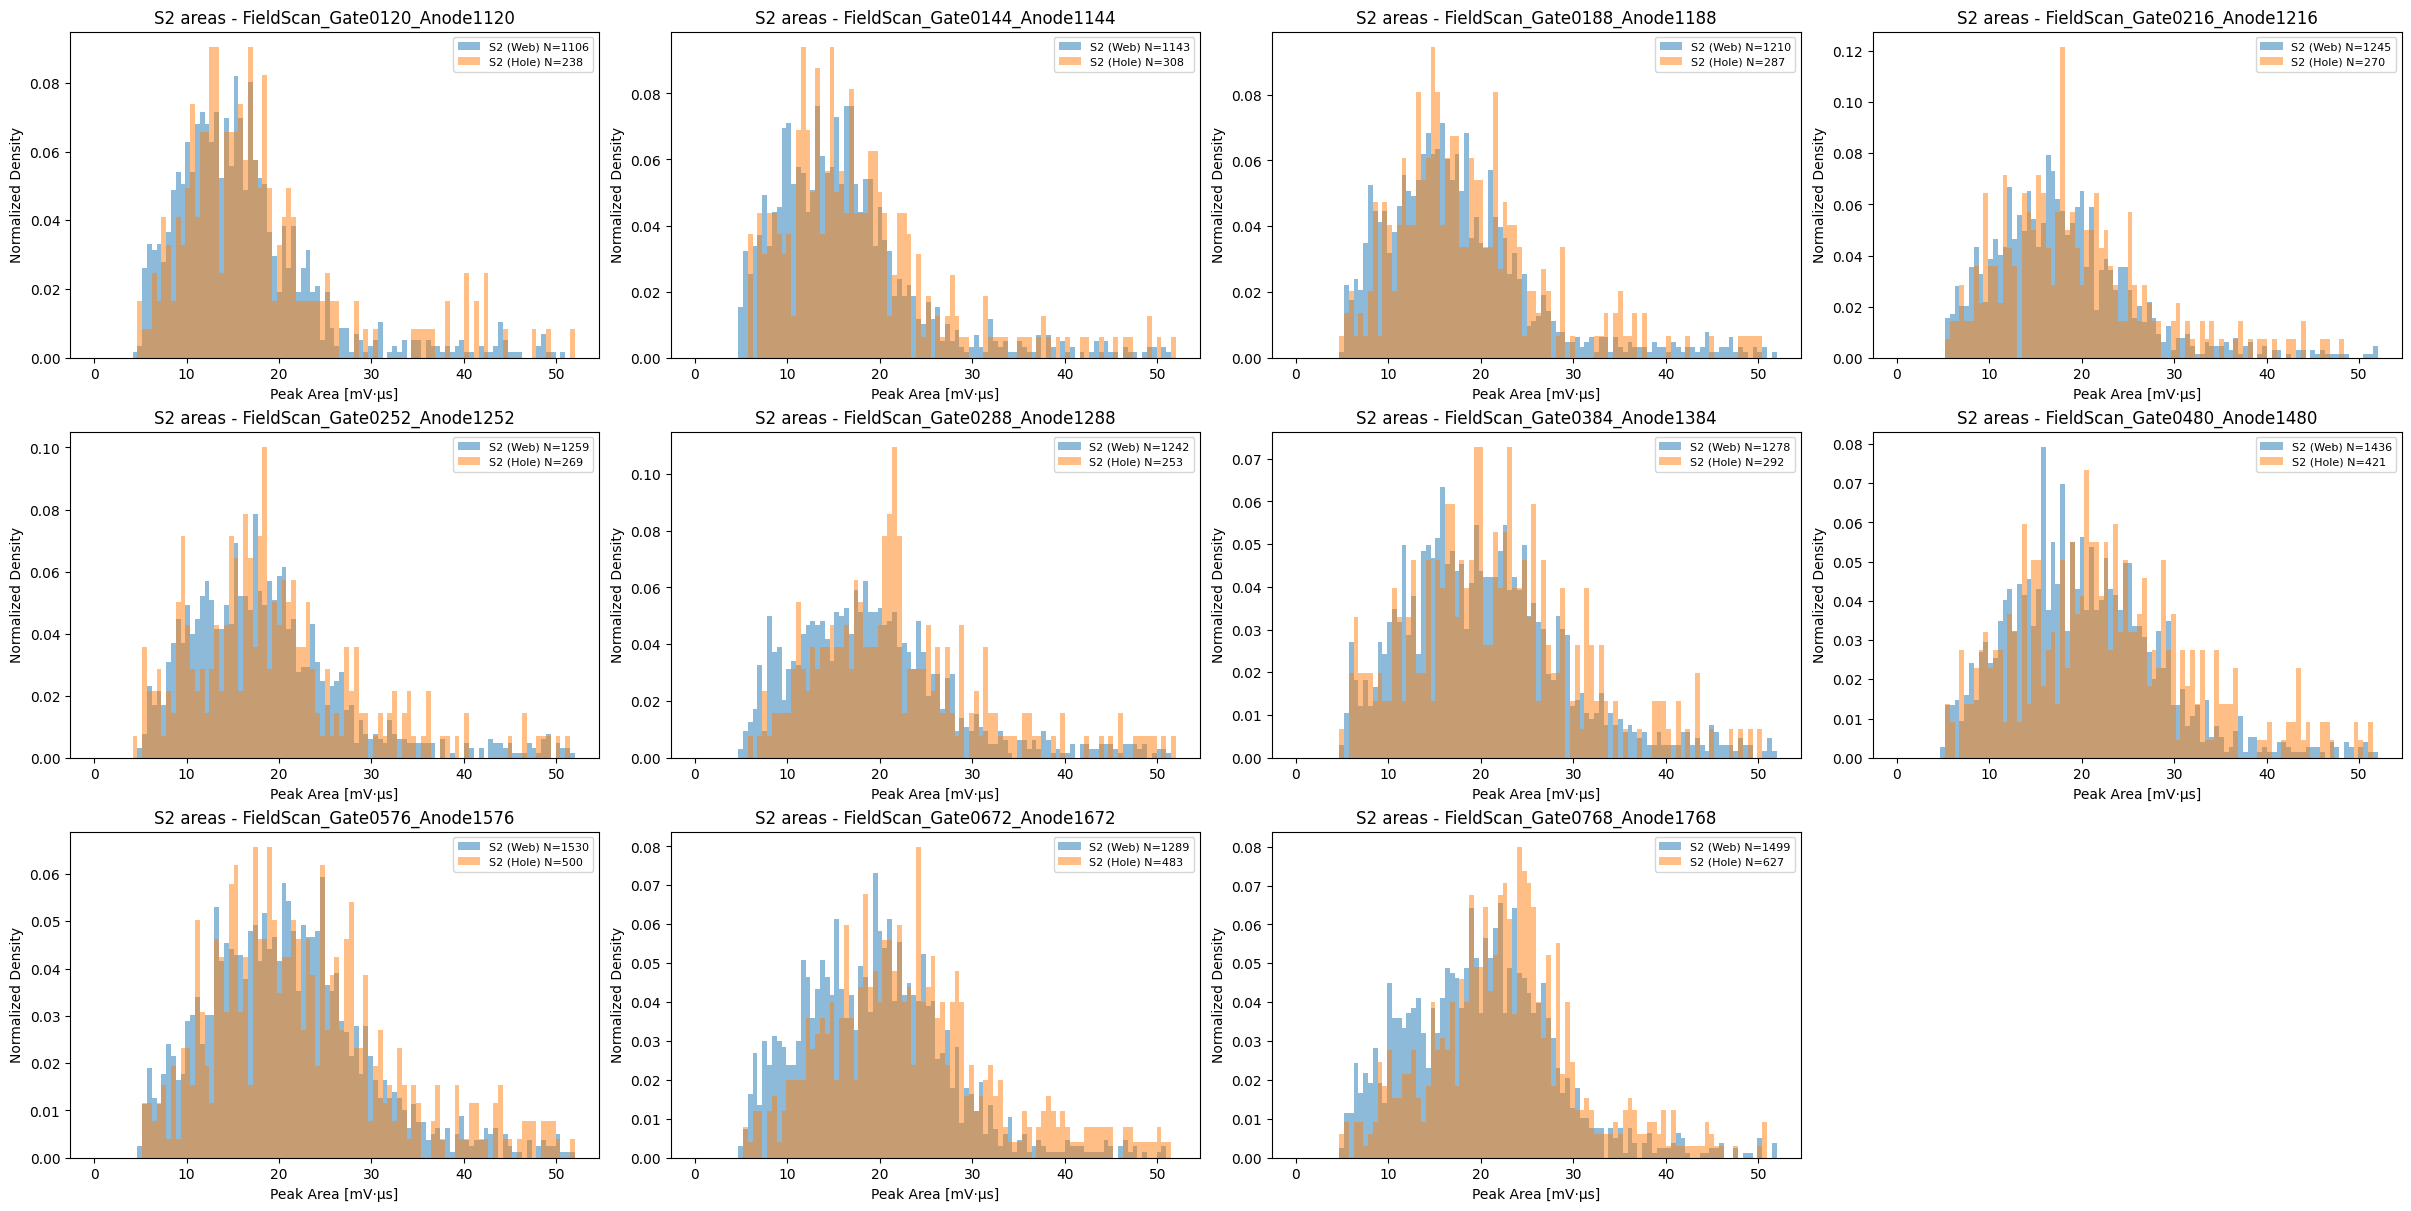

In [106]:
cols = math.ceil(math.sqrt(len(files)))
rows = math.ceil(len(files) / cols) if cols > 0 else 1

# --- To plot S1 Distributions (with GMM fits) ---
fig_s1, ax_s1 = plt.subplots(nrows=rows, ncols=cols, figsize=(cols*6, rows*4), constrained_layout=True)
ax_s1 = np.atleast_2d(ax_s1) # Ensure 2D addressing works even if 1 row

for i, f in enumerate(files):
    row, col = divmod(i, cols)
    plot_s1_area_distribution(f, ax=ax_s1[row, col])

# Turn off empty axes
for j in range(i + 1, rows * cols):
    ax_s1[j // cols, j % cols].axis('off')
    

# --- To plot S2 Distributions (The A/B Test) ---
fig_s2, ax_s2 = plt.subplots(nrows=rows, ncols=cols, figsize=(cols*6, rows*4), constrained_layout=True)
ax_s2 = np.atleast_2d(ax_s2)

for i, f in enumerate(files):
    row, col = divmod(i, cols)
    plot_s2_area_distribution(f, ax=ax_s2[row, col])

for j in range(i + 1, rows * cols):
    ax_s2[j // cols, j % cols].axis('off')

In [50]:
len(files)

11

  Fit success: True, χ²/DOF: 1.68


/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


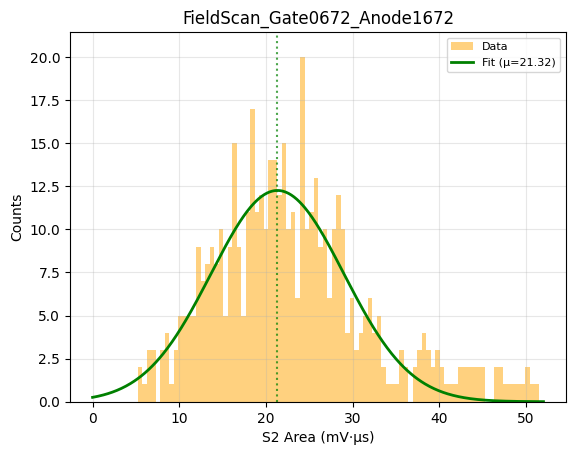

In [107]:
s2_areas_web, s2_areas_tail = plot_s2_area_distribution(files[9], ax=None)
plt.clf()

result9 = fit_s2_crystalball(s2_areas_tail.areas, bin_cuts=(1, 52), nbins=100)

plot_s2areas_summary(ax=plt.gca(), set_name=run.sets[9].source_dir.name, s2_areas=s2_areas_tail, fit_model=result9['result'], bin_cuts=(0, 52))

In [111]:
set9 = run.sets[9]
metadata_updates = {
        'area_s2_mean': result9['peak_position'],
        'area_s2_ci95': result9['ci95'],
        'area_s2_sigma': result9['sigma'],
        'area_s2_fit_success': True,
        's2_background_bound': result9['lower_bound']
    }
set9u = replace(set9, **metadata_updates)
sets = run.sets
sets[9] = set9u
run = replace(run, sets=sets)

  Fit success: True, χ²/DOF: 4.43


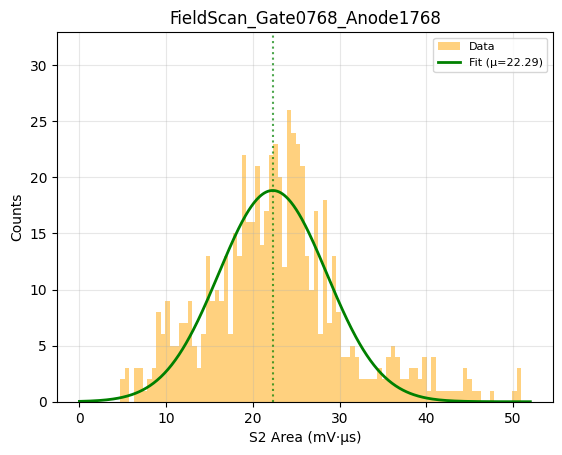

In [108]:
s2_areas_web, s2_areas_tail = plot_s2_area_distribution(files[10], ax=None)
plt.clf()

result10 = fit_s2_crystalball(s2_areas_tail.areas, bin_cuts=(1, 52), nbins=100)

plot_s2areas_summary(ax=plt.gca(), set_name=run.sets[10].source_dir.name, s2_areas=s2_areas_tail, fit_model=result10['result'], bin_cuts=(0, 52))

In [109]:
set9 = run.sets[10]
metadata_updates = {
        'area_s2_mean': result10['peak_position'],
        'area_s2_ci95': result10['ci95'],
        'area_s2_sigma': result10['sigma'],
        'area_s2_fit_success': True,
        's2_background_bound': result10['lower_bound']
    }
set9u = replace(set9, **metadata_updates)
sets = run.sets
sets[10] = set9u
run = replace(run, sets=sets)

In [112]:
run = map_recoil_plots(run, config=FitConfig(), force=True)


GENERATING RECOIL S2 AREAS QA PLOTS: RUN_32
  Loaded fit model for FieldScan_Gate0120_Anode1120 with lower_bound=7.75
  Loaded fit model for FieldScan_Gate0144_Anode1144 with lower_bound=8.25
  Loaded fit model for FieldScan_Gate0188_Anode1188 with lower_bound=8.75
  Loaded fit model for FieldScan_Gate0216_Anode1216 with lower_bound=7.75
  Loaded fit model for FieldScan_Gate0252_Anode1252 with lower_bound=7.25
  Loaded fit model for FieldScan_Gate0288_Anode1288 with lower_bound=6.25
  Loaded fit model for FieldScan_Gate0384_Anode1384 with lower_bound=7.25
  Loaded fit model for FieldScan_Gate0480_Anode1480 with lower_bound=7.25
  Loaded fit model for FieldScan_Gate0576_Anode1576 with lower_bound=9.25
  Loaded fit model for FieldScan_Gate0672_Anode1672 with lower_bound=6.355
  Loaded fit model for FieldScan_Gate0768_Anode1768 with lower_bound=5.845
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN32_EL25k/plots/s2_areas/RUN_32_histograms.png
  → Saved: /Volumes/KINGSTON/RaTag_data/

### Other 2D histograms

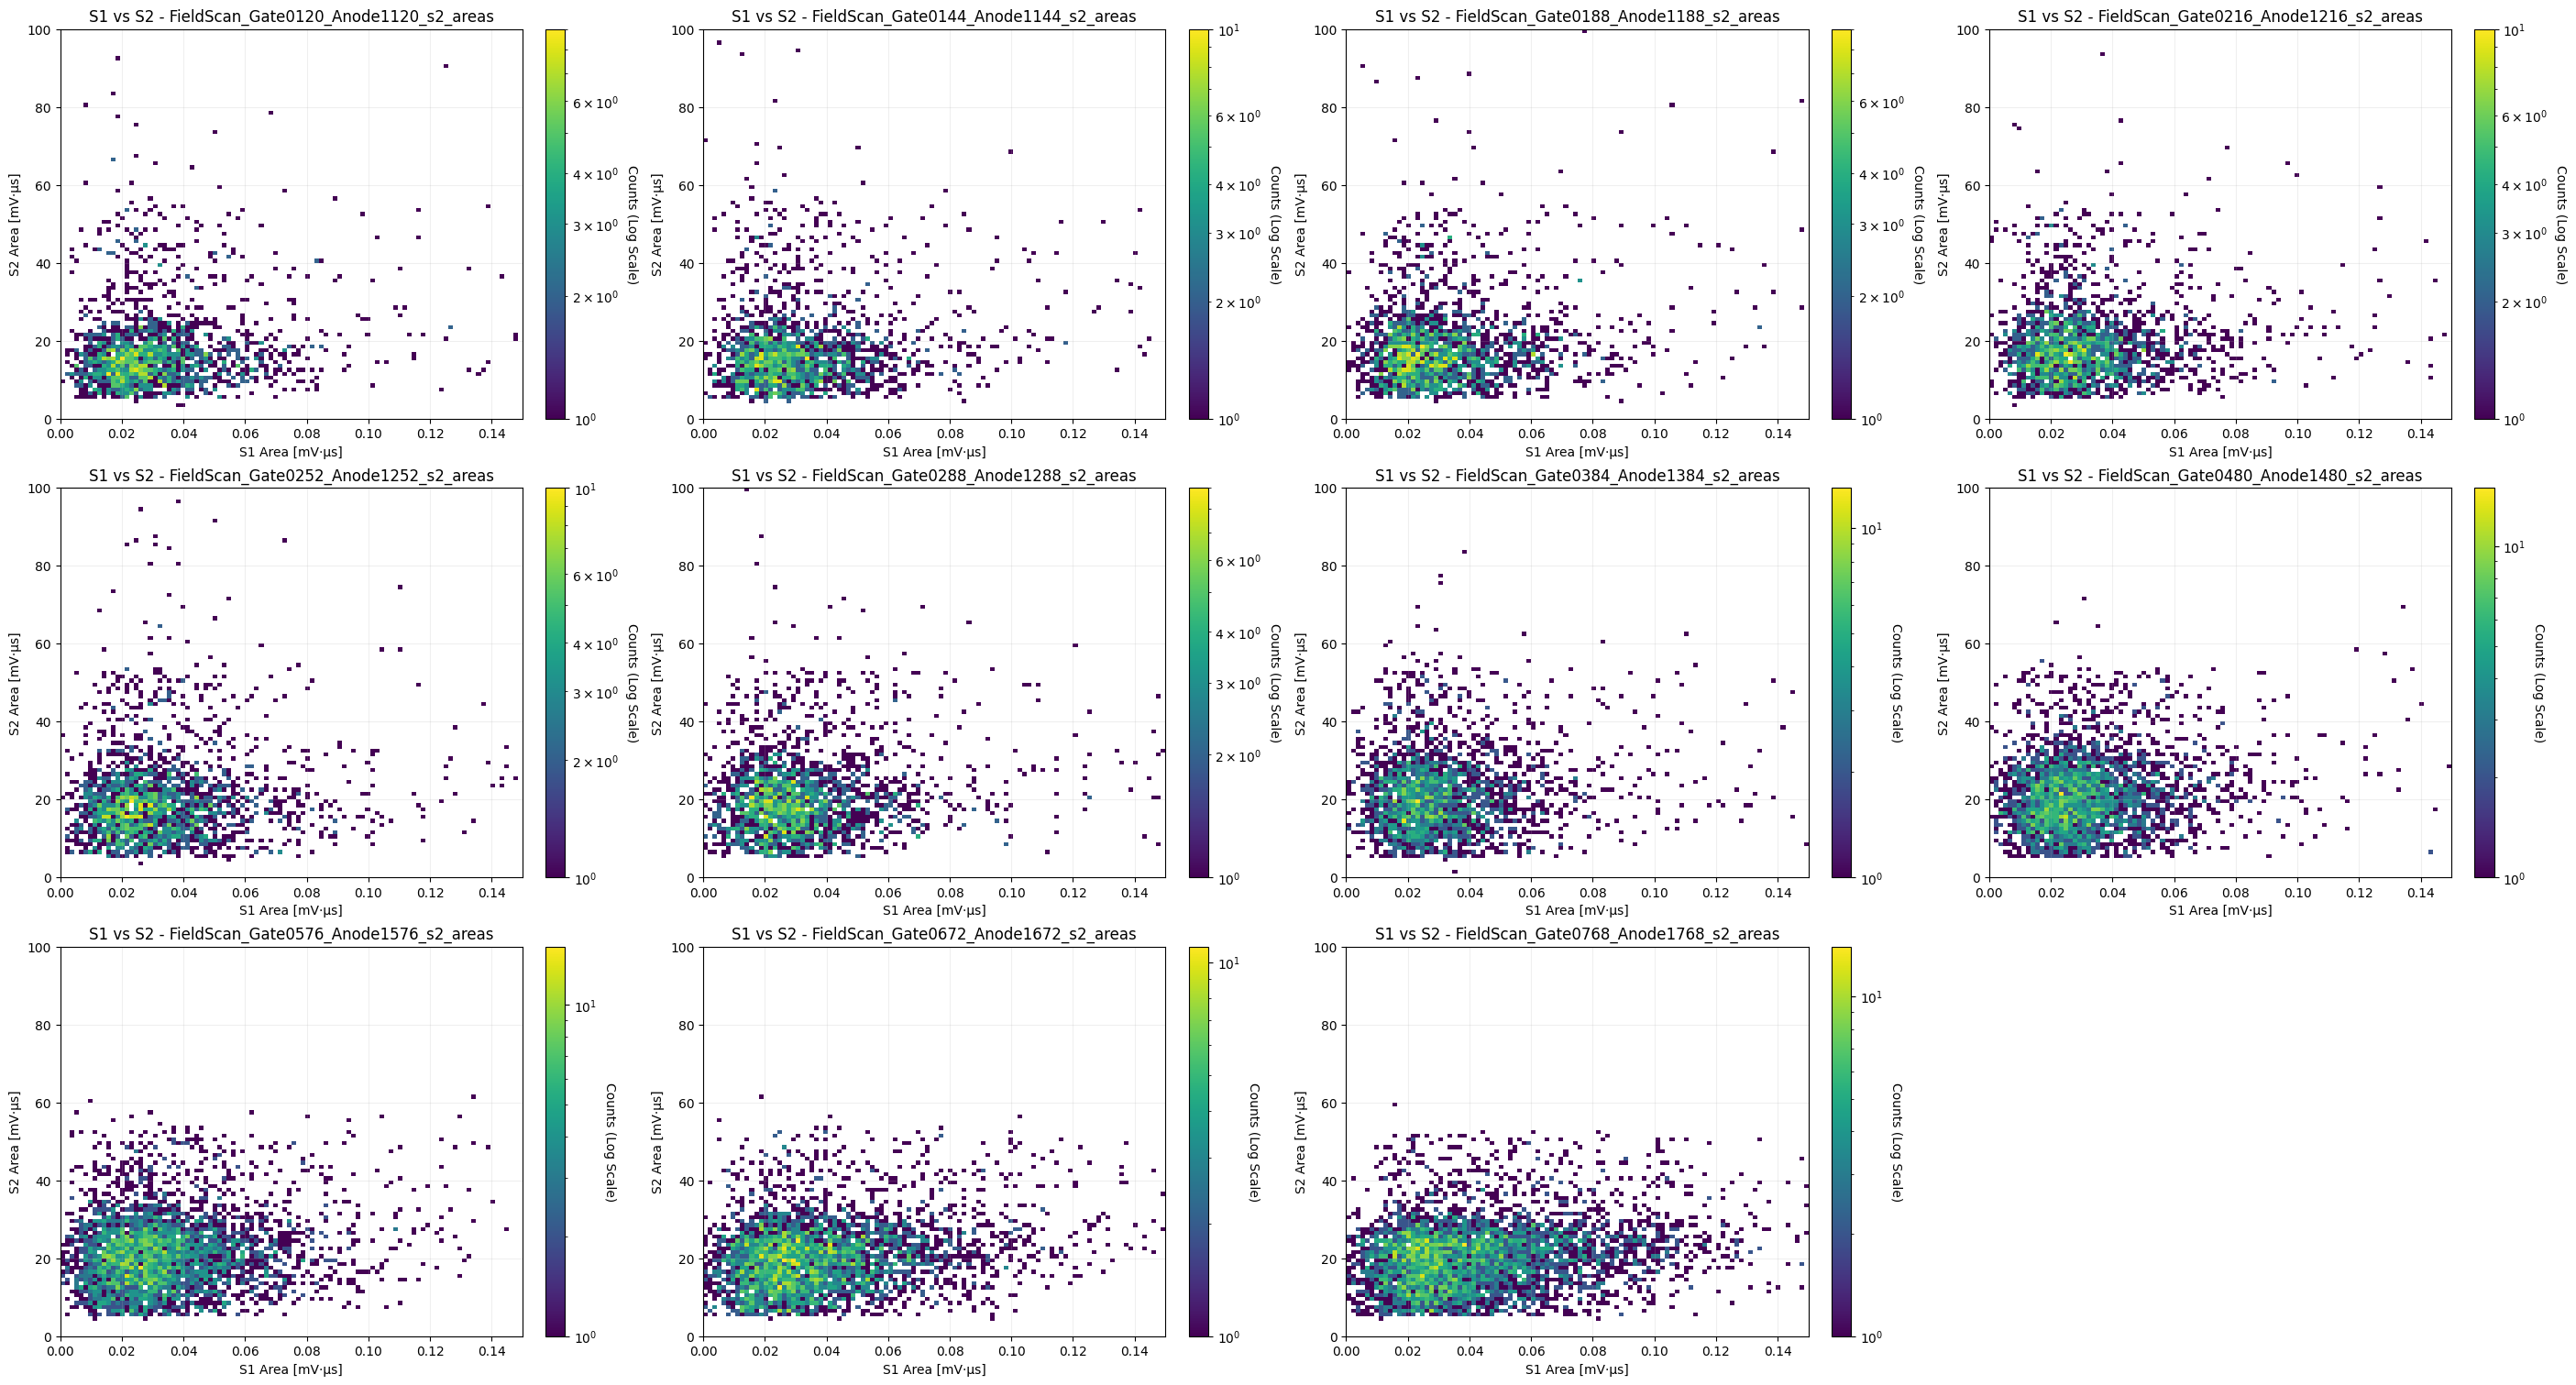

In [ ]:

cols = math.ceil(math.sqrt(len(files)))
rows = math.ceil(len(files) / cols) if cols > 0 else 1

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(cols*7, rows*5), constrained_layout=True)
axes = np.atleast_2d(axes)

for i, f in enumerate(files):
    row, col = divmod(i, cols)
    plot_s1_vs_s2_2d(f, ax=axes[row, col])

for j in range(i + 1, rows * cols):
    axes[j // cols, j % cols].axis('off')
    
plt.show()

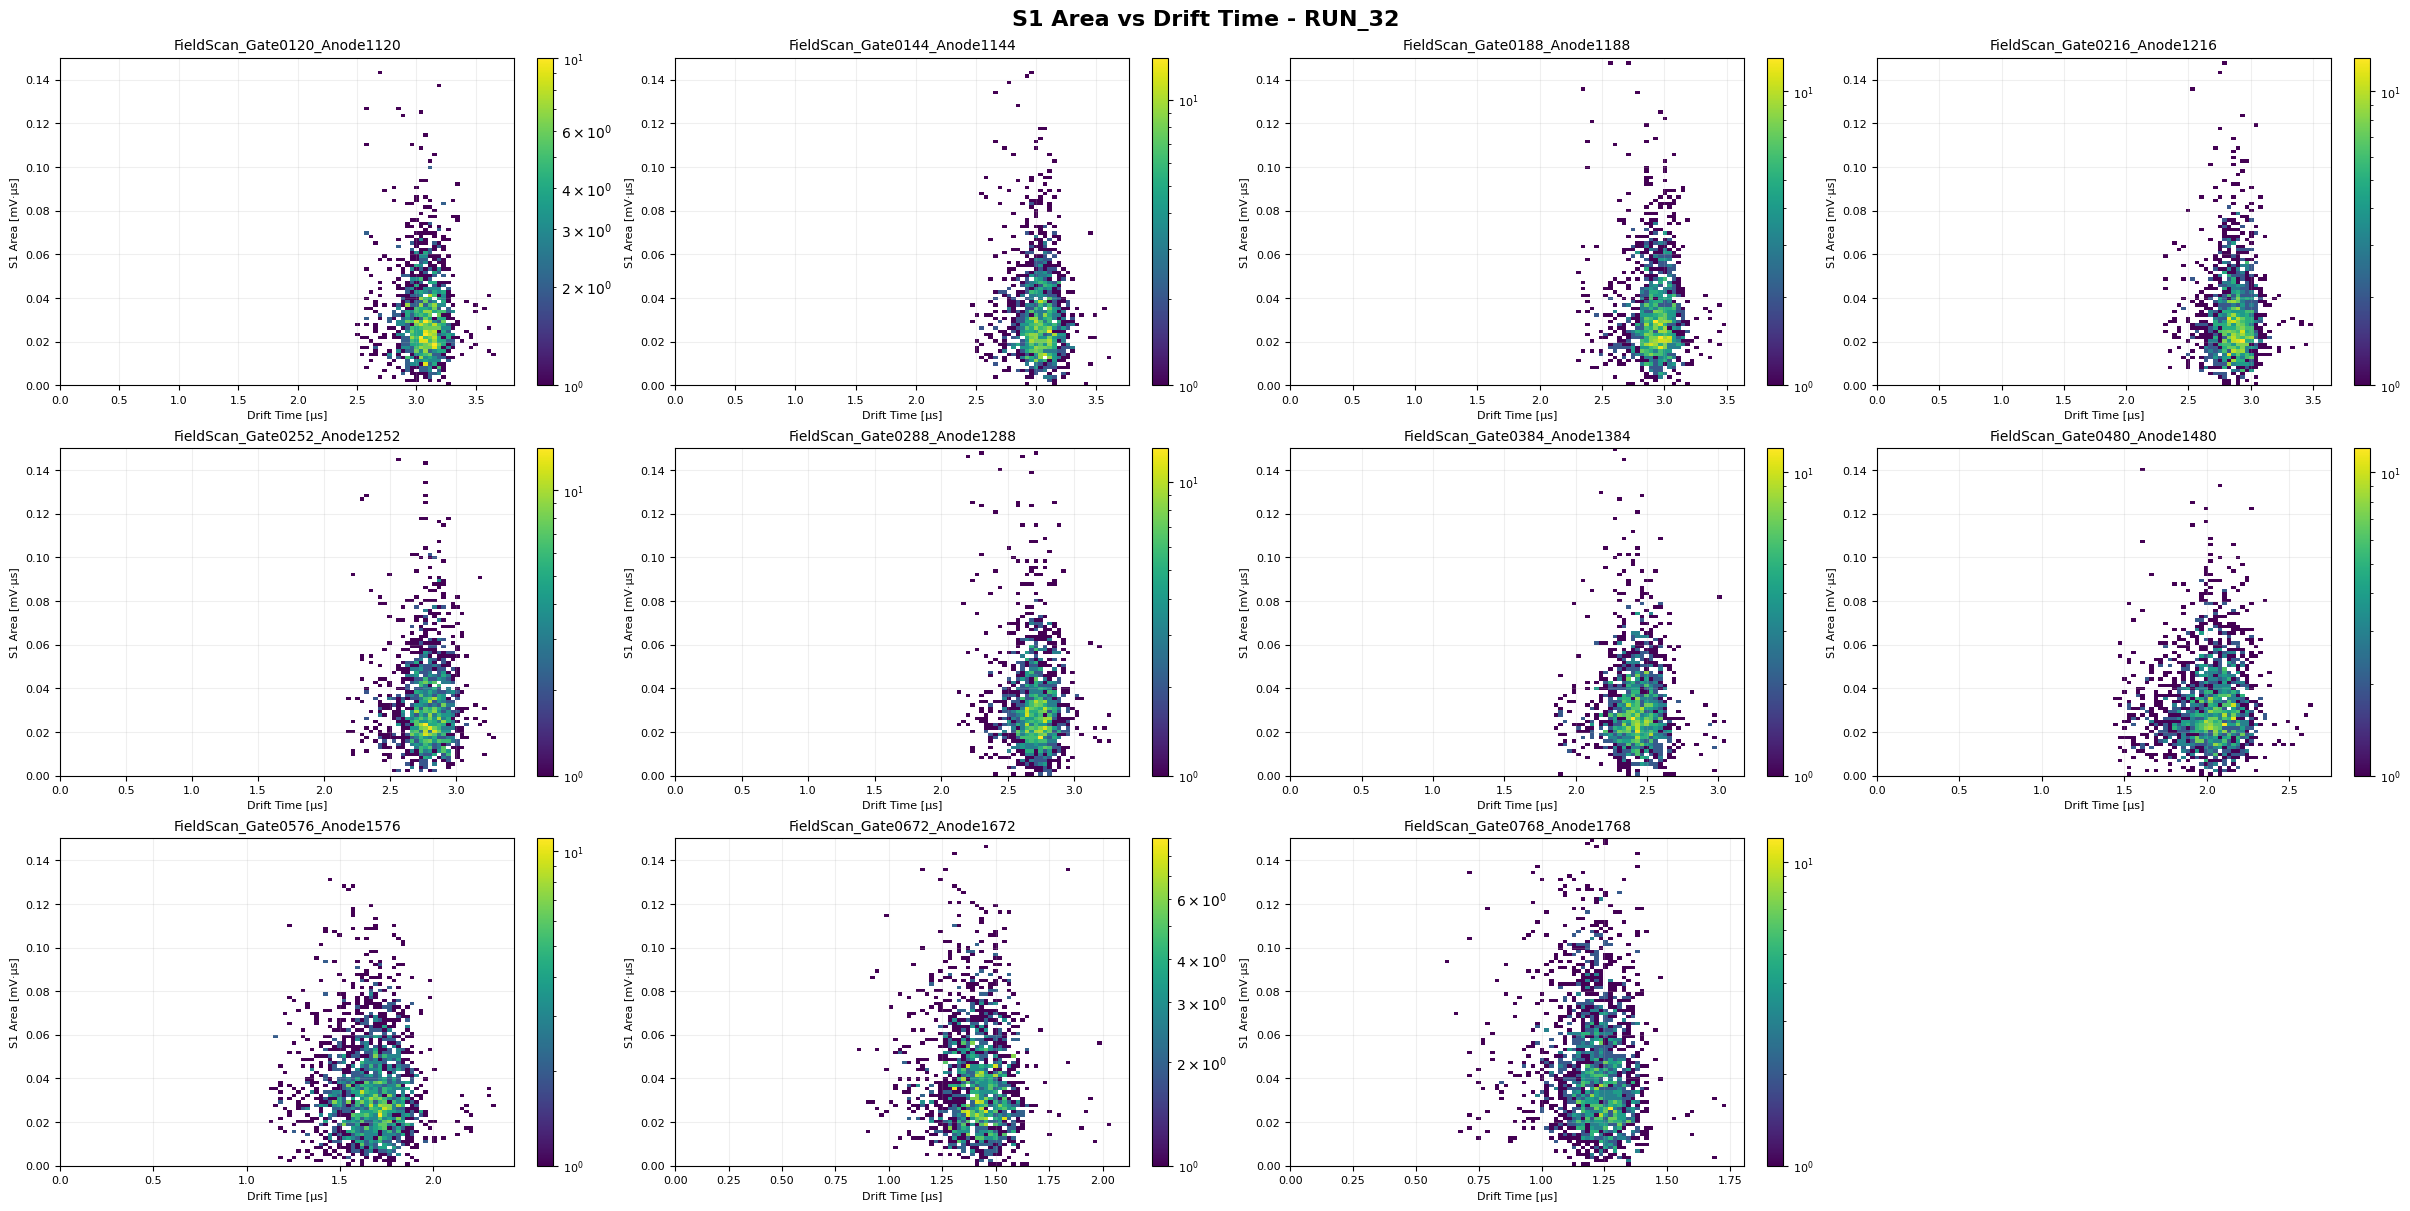

In [104]:
n_sets = len(run.sets)
if n_sets == 0:
    print("No sets found in run.")
    
cols = math.ceil(math.sqrt(n_sets))
rows = math.ceil(n_sets / cols) if cols > 0 else 1

# Build the figure
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(cols*6, rows*4), constrained_layout=True)
axes = np.atleast_2d(axes) # Protect against 1D grids

fig.suptitle(f"S1 Area vs Drift Time - {run.run_id}", fontsize=16, fontweight='bold')

for i, set_pmt in enumerate(run.sets):
    row, col = divmod(i, cols)
    ax = axes[row, col]
    
    success = plot_set_s1_vs_drift_time(set_pmt, ax=ax)
    
    if not success:
        ax.text(0.5, 0.5, "Insufficient Data", ha='center', va='center', color='red')
        ax.set_title(set_pmt.source_dir.name, fontsize=10)
        
# Turn off completely empty axes at the end of the grid
for j in range(i + 1, rows * cols):
    axes[j // cols, j % cols].axis('off')


# Check individual waveforms

In [438]:
from RaTag.plotting import plot_full_coincidence_diagnostic, plot_waveform
from RaTag.io.file_ops import load_s1areas, load_npz_arrays, load_waveform_by_uid, extract_single_frame, load_wfm
from RaTag.io.file_ops import iter_waveforms

In [34]:
path = Path('/Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/s2_areas')
files = list(path.glob('*.npz'))
uids = np.load(files[0])['uids']
set9 = run.sets[6]
set9.source_dir.name

'FieldScan_Gate0480_Anode1480'

In [30]:
alpha_file = '/Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/alpha_energies/FieldScan_Gate0480_Anode1280_alpha_energies.npz'
np.load(alpha_file)['uids']

array([  64,   65,   66, ..., 2264, 2265, 2266])

In [134]:
s1_data = load_s1areas(set9)
timing_data = load_npz_arrays(set9, signal_type='timing')
# timing_data

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/s2_areas/FieldScan_Gate0480_Anode1280_s2_areas.npz
  Loading timing arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/timing/FieldScan_Gate0480_Anode1280_timing.npz


In [84]:
files

[PosixPath('/Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/s2_areas/FieldScan_Gate0480_Anode1480_s2_areas.npz')]

In [135]:
[s.name for s in run.sets]

['FieldScan_Gate0120_Anode0920',
 'FieldScan_Gate0156_Anode0956',
 'FieldScan_Gate0188_Anode0988',
 'FieldScan_Gate0216_Anode1016',
 'FieldScan_Gate0288_Anode1088',
 'FieldScan_Gate0384_Anode1184',
 'FieldScan_Gate0480_Anode1280',
 'FieldScan_Gate0576_Anode1376',
 'FieldScan_Gate0672_Anode1472',
 'FieldScan_Gate0768_Anode1568']

In [137]:
files[0]

PosixPath('/Volumes/KINGSTON/RaTag_data/processed/RUN36_EL25kVcm/s2_areas/FieldScan_Gate0480_Anode1480_s2_areas.npz')

In [12]:
from RaTag.core.uid_utils import generate_all_uids_for_set, decode_uid, parse_file_seq_from_name


In [17]:
file_seq, frame_idx = decode_uid(uids[0])
# Find the corresponding filename in the set
target_fn = next((fn for fn in set9.filenames if parse_file_seq_from_name(fn) == file_seq), None)
file_seq, frame_idx

(np.int64(20260721), np.int64(56))

In [15]:
parse_file_seq_from_name(set9.filenames[0])

1

In [20]:
def plot_full_coincidence_diagnostic(wf, config, frame_idx=0, ax=None):
    """
    Step-by-step diagnostic of the exact coincidence math.
    Updated for the 'First-Peak' (Chronological) S1 finding logic and Late S2 cuts.
    """
    from scipy.ndimage import maximum_filter1d
    from RaTag.waveform.preprocessing import subtract_pedestal, moving_average, threshold_clip
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 8))
        
    # --- 1. Preprocessing ---
    wf_single = replace(wf, v=wf.v[[frame_idx]] if wf.ff else wf.v, nframes=1)
    wf_sub = subtract_pedestal(wf_single, config.n_pedestal)
    
    t = wf_single.t
    v_raw = wf_single.v[0] if wf_single.ff else wf_single.v
    v_sub = wf_sub.v[0] if wf_single.ff else wf_sub.v
    dt = t[1] - t[0]

    
    # --- 3. EXACT find_s2 Logic ---
    t_min_s2 = -2.5
    # wf_smooth = moving_average(wf_single, window=config.s2_window_ma)
    wf_clip = threshold_clip(wf_single, threshold=config.bs_threshold)
    v_clip = wf_clip.v[0] if wf_clip.ff else wf_clip.v
    
    s2_mask = t > t_min_s2
    t_s2_sliced = t[s2_mask]
    v_s2_sliced = v_clip[s2_mask]
    v_envelope = maximum_filter1d(v_s2_sliced, size=500)


    # 2. Find the peak on the raw slice to keep your true maximum
    s2_peak_idx = np.argmax(v_s2_sliced)
    s2_time = t_s2_sliced[s2_peak_idx]
    s2_height = v_s2_sliced[s2_peak_idx]

    # 3. Calculate dynamic threshold
    dyn_thresh = max(s2_height * config.s2_fraction, config.s2_threshold)

    # 4. Search for boundaries using the ENVELOPE, not the raw slice
    below_thresh = v_envelope <= dyn_thresh
    
    pass_s2_height = s2_height > config.s2_threshold
    
    
    left_mask = np.arange(len(v_s2_sliced)) <= s2_peak_idx
    valid_below_left = below_thresh & left_mask
    start_idx = len(v_s2_sliced) - 1 - np.argmax(np.fliplr([valid_below_left])[0]) if np.any(valid_below_left) else 0
    s2_start = t_s2_sliced[min(start_idx + 1, len(v_s2_sliced) - 1)]
    
    right_mask = np.arange(len(v_s2_sliced)) >= s2_peak_idx
    valid_below_right = below_thresh & right_mask
    end_idx = np.argmax(valid_below_right) if np.any(valid_below_right) else len(v_s2_sliced) - 1
    s2_end = t_s2_sliced[max(end_idx - 1, 0)]
    
    s2_width = s2_end - s2_start
    s2_int_mask = (t >= s2_time - 1.5) & (t <= s2_time + 1.5)
    s2_area = np.sum(v_sub * s2_int_mask) * dt
    
    # Check for your new s2_start_max cut (Defaults to 0.5 if not in config)
    s2_start_max = getattr(config, 's2_start_max', 0.5) 
    pass_s2_start_late = s2_start <= s2_start_max
    
    pass_s2_width = s2_width >= config.s2_min_width
    pass_s2_area_min = s2_area >= config.s2_min_area
    pass_s2_area_max = s2_area <= config.s2_max_area
    s2_valid = pass_s2_height and pass_s2_width and pass_s2_area_min and pass_s2_area_max and (s2_peak_idx > 0) and pass_s2_start_late
    
    # --- 4. Plotting ---
    ax.plot(t, v_raw, color='gray', alpha=0.3, label='Raw Waveform')
    ax.plot(t, v_sub, color='blue', lw=0.3, label='Pedestal Subtracted')
    ax.plot(t_s2_sliced, v_envelope, color='green', lw=1.0, alpha=0.7, label='S2 Envelope (Max Filter)')
    # ax.plot(t, v_clip, color='purple', lw=1.0, alpha=0.9, label='S2 Smoothed/Clipped')
    ax.axhline(0, color='black', lw=0.8, linestyle='-')
    
    # Visual Threshold line for First-Peak finding
    ax.axhline(dyn_thresh, color='orange', lw=1.5, linestyle=':', label=f'S2 Threshold ({config.s2_threshold} mV)')
    
    # # S1 Visuals
    # ax.axvspan(config.s1_t_min, config.s1_t_max, color='yellow', alpha=0.1, label='S1 Search Window')
    # ax.axvspan(s1_time - 0.05, s1_time + 0.05, color='green', alpha=0.2, label='S1 Integration')
    # marker_color = 'r*' if s1_valid else 'kx'
    # ax.plot(s1_time, s1_height, marker_color, markersize=10, label=f'S1 Anchor ({anchor_type})')
    
    # S2 Visuals
    ax.axvspan(s2_start, s2_end, color='red', alpha=0.1, label='Found S2 Boundaries')
    if not pass_s2_start_late:
        ax.axvline(s2_start_max, color='red', linestyle='--', label=f's2_start_max Cut ({s2_start_max} µs)')
    
    # --- 5. Diagnostic Text Box ---
    # s1_status = "PASS" if s1_valid else "FAIL"
    s2_status = "PASS" if s2_valid else "FAIL"
    coinc_status = "ACCEPTED" if s2_valid else "REJECTED"
    
    text_str = (
        f"Frame {frame_idx} Diagnostics | Final Status: {coinc_status}\n"
        f"----------------------------------------------------\n"
        # f"S1 CUTS (Status: {s1_status})\n"
        # f" Anchor: {anchor_type} @ {s1_time:.3f} µs\n"
        # f" Height: {s1_height:.2f} mV\t[{config.s1_v_min} - {config.s1_v_max}]\t-> {'PASS' if pass_s1_height else 'FAIL'}\n"
        # f" Area:   {s1_area:.4f} mV*µs\t[0.0 - {config.s1_max_area}]\t-> {'PASS' if pass_s1_area else 'FAIL'}\n"
        f"----------------------------------------------------\n"
        f"S2 CUTS (Status: {s2_status})\n"
        f" Height: {s2_height:.2f} mV\t[> {config.s2_threshold}]\t\t-> {'PASS' if pass_s2_height else 'FAIL'}\n"
        f" Width:  {s2_width:.2f} µs\t[> {config.s2_min_width}]\t\t-> {'PASS' if pass_s2_width else 'FAIL'}\n"
        f" Area:   {s2_area:.1f} mV*µs\t[{config.s2_min_area} - {config.s2_max_area}]\t-> {'PASS' if (pass_s2_area_min and pass_s2_area_max) else 'FAIL'}\n"
        f" Start:  {s2_start:.2f} µs\t[<= {s2_start_max}]\t\t-> {'PASS' if pass_s2_start_late else 'FAIL (Late S2)'}\n"
        f" Index0 Trap Avoided: \t\t\t-> {'PASS' if s2_peak_idx > 0 else 'FAIL (Tail Slice)'}"
    )
    
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black')
    ax.text(0.02, 0.95, text_str, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props, family='monospace')
            
    # ax.set_ylim(-5.0, min(max(s1_height, s2_height) * 1.2, 50.0))
    ax.set_xlabel('Time (µs)')
    ax.set_ylabel('Signal (mV)')
    ax.legend(loc='upper right', fontsize=8)
    
    if ax is None:
        plt.show()
    return ax

In [12]:
frame_idx = 0
file_idx = 0

[(-5.0, 50.0)]

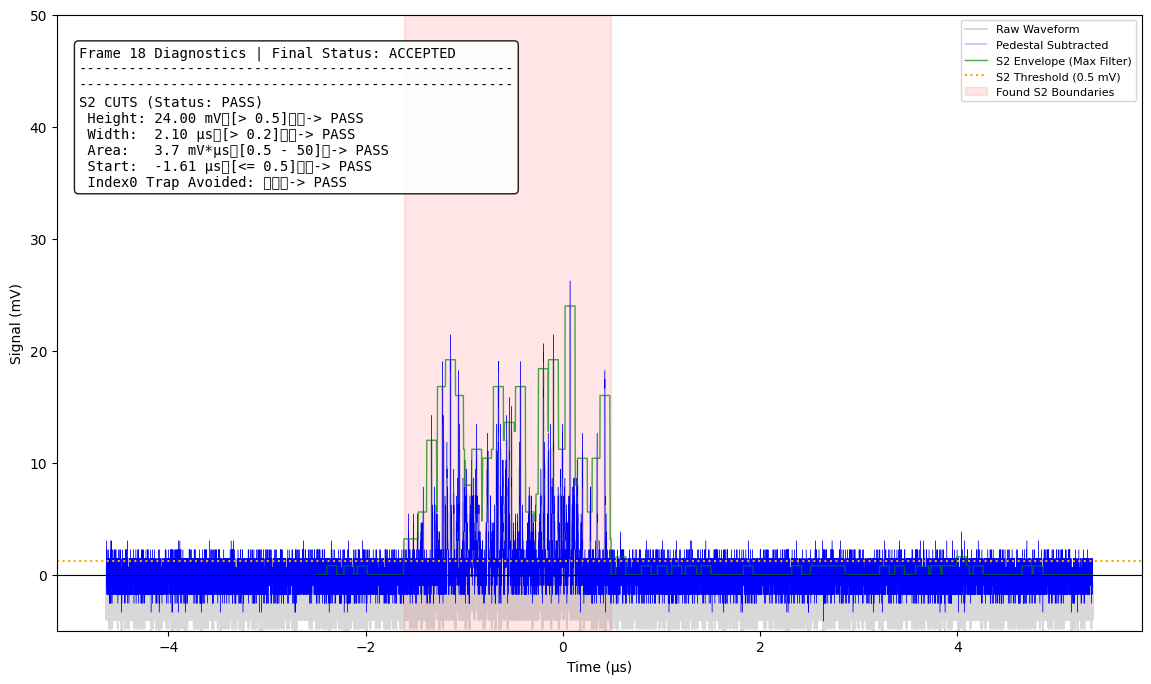

In [34]:
frame_idx += 1
wf = load_wfm(set9.source_dir / set9.filenames[file_idx])
wf = extract_single_frame(wf, frame_idx)
# plot_waveform(wf, title=f"Waveform for UID {uid}")

ax = plot_full_coincidence_diagnostic(wf, config=TimingConfig(s2_window_ma=20), frame_idx=frame_idx)
ax.set(ylim=(-5.0, 50.0))

In [35]:
frame_idx = 0

In [36]:
set9.drift_field

1000.0

In [87]:
[(wf.v[frame, :] > 150).any() for frame in range(wf.nframes)]

[np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.True_,
 np.True_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.True_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.True_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.True_,
 np.True_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.True_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,
 np.True_,
 np.False_,
 np.False_,
 np.False_,
 np.False_,


[(4.5, 5.5), (150.0, 170.0)]

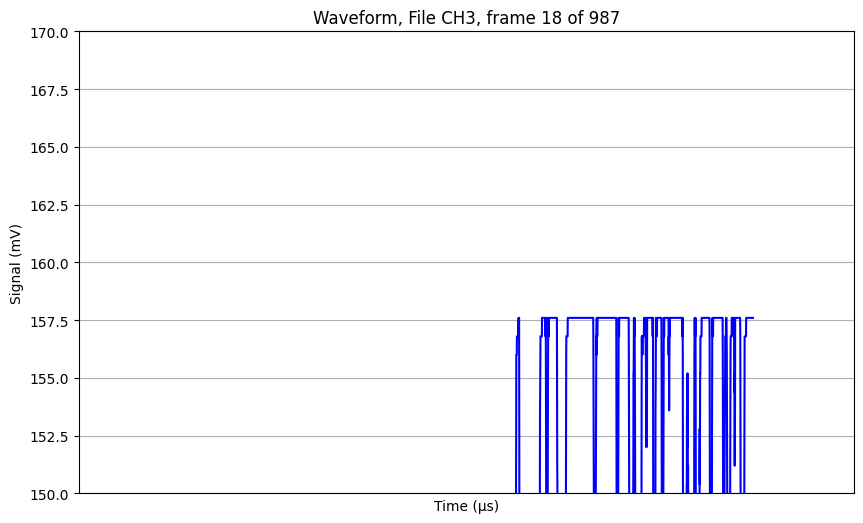

In [77]:
plot_waveform(wf, frame=18)
plt.gca().set(xlim=(4.5, 5.5), ylim=(150, 170))

In [105]:
i = 0

In [248]:
len(wf.t)

50000

In [432]:
from RaTag.waveform.preprocessing import moving_average, subtract_pedestal
from scipy.ndimage import maximum_filter1d

def find_s2(wf):
    # 1. Base parameters & preprocessing
    s2_threshold = 150
    t_min_s2 = -2.0
    s2_fraction = 0.2
    s2_min = 0.5
    s2_max = 50.0  

    is_clipped = np.any(wf.v >= s2_threshold, axis=1)
    has_no_clips = ~is_clipped

    wf_sub = subtract_pedestal(wf, n_points=200)
    v_envelope = maximum_filter1d(wf_sub.v, size=1000, axis=1)
    wf_smooth = replace(wf_sub, v=v_envelope, nframes=wf_sub.nframes)

    mask = wf_smooth.t > t_min_s2
    t_sliced = wf_smooth.t[mask]
    v_sliced = wf_smooth.v[:, mask] if wf_smooth.ff else wf_smooth.v[mask][np.newaxis, :]

    # 2. Anchor to Global Maximum & Find Boundaries
    peak_idx = np.argmax(v_sliced, axis=1)
    peak_heights = v_sliced[np.arange(len(v_sliced)), peak_idx]
    peak_times = t_sliced[peak_idx]
        
    dynamic_thresh = (peak_heights * s2_fraction)[:, np.newaxis]
    below_thresh = v_sliced <= dynamic_thresh
    idx_2d = np.arange(v_sliced.shape[1])[np.newaxis, :]

    # Left boundary search
    left_mask = idx_2d <= peak_idx[:, np.newaxis]
    valid_left = below_thresh & left_mask
    first_below_left_rev = np.argmax(np.fliplr(valid_left), axis=1)
    start_time = t_sliced[np.clip(v_sliced.shape[1] - 1 - first_below_left_rev, 0, v_sliced.shape[1] - 1)]

    # Right boundary search
    right_mask = idx_2d >= peak_idx[:, np.newaxis]
    valid_right = below_thresh & right_mask
    last_below_right = np.argmax(valid_right, axis=1)
    end_time = t_sliced[np.clip(last_below_right - 1, 0, v_sliced.shape[1] - 1)]

    # 3. Area Integration
    dt = wf_sub.t[1] - wf_sub.t[0]
    t_2d = wf_sub.t[np.newaxis, :]
    s2_mask = (t_2d >= start_time[:, np.newaxis]) & (t_2d <= end_time[:, np.newaxis])
    s2_areas = np.sum(wf_sub.v * s2_mask, axis=1) * dt

    # 4. COMBINE ALL CUTS VECTORIALLY
    # Check if left and right searches successfully found valid boundaries (did not default entirely)
    has_valid_left = np.any(valid_left, axis=1)
    has_valid_right = np.any(valid_right, axis=1)

    # Assemble the final acceptance filter mask
    accepted_events = (
        has_no_clips & 
        has_valid_left & 
        has_valid_right & 
        (s2_areas > s2_min) & 
        (s2_areas < s2_max)
    )

    filtered_areas = s2_areas[accepted_events]
    filtered_peak_times = peak_times[accepted_events]
    filtered_start_times = start_time[accepted_events]
    filtered_end_times = end_time[accepted_events]
    return {
        'areas': filtered_areas,
        'peak_times': filtered_peak_times,
        'start_times': filtered_start_times,
        'end_times': filtered_end_times,
        'accepted_events': accepted_events
    }


In [460]:
areas, peak_times, start_times, end_times, accepted_events = [], [], [], [], []
for wf in iter_waveforms(set9, max_files=1): 
    res_dict = find_s2(wf)
    areas.append(res_dict['areas'])
    peak_times.append(res_dict['peak_times'])
    start_times.append(res_dict['start_times'])
    end_times.append(res_dict['end_times'])

areas = np.concatenate(areas)
peak_times = np.concatenate(peak_times)
start_times = np.concatenate(start_times)
end_times = np.concatenate(end_times)

In [465]:
len(areas)

462

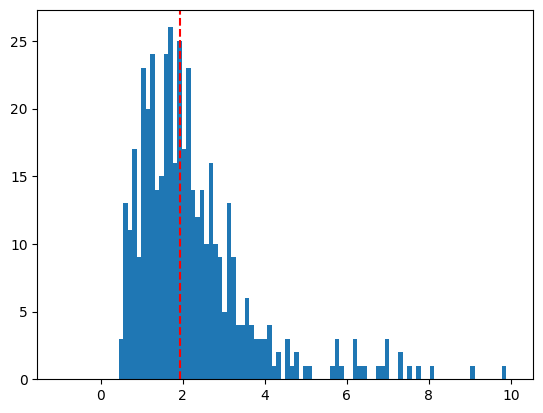

In [466]:
plt.hist(areas, bins=100, range=(-1, 10));#
plt.axvline(np.median(areas), color='red', linestyle='--', label='Median Area')

In [462]:
np.median(peak_times), np.median(end_times) - np.median(start_times)

(np.float64(1.8816999999999997), np.float64(1.5956000000000006))

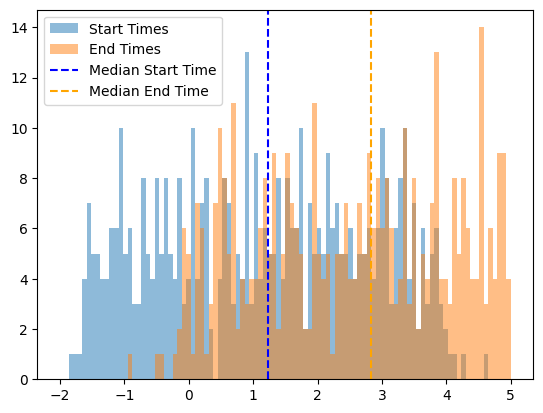

In [463]:
# plt.hist(res_dict['peak_times'], bins=100, range=(-2, 5), alpha=0.5, label='Peak Times');
plt.hist(start_times, bins=100, range=(-2, 5), alpha=0.5, label='Start Times');
plt.hist(end_times, bins=100, range=(-2, 5), alpha=0.5, label='End Times');
plt.axvline(np.median(start_times), color='blue', linestyle='--', label='Median Start Time')
plt.axvline(np.median(end_times), color='orange', linestyle='--', label='Median End Time')

plt.legend()


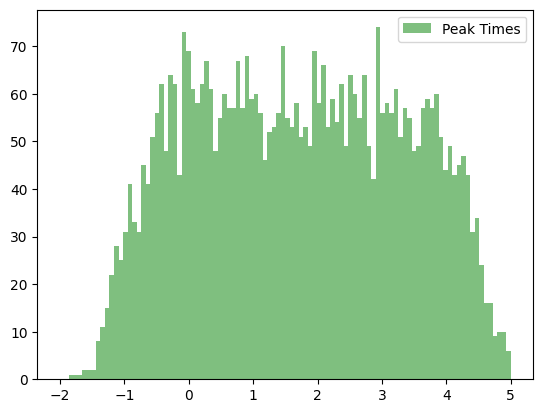

In [457]:
plt.hist(peak_times, bins=100, range=(-2, 5), color='green', alpha=0.5, label='Peak Times');
plt.legend()

(<Axes: title={'center': 'Waveform for frame 223, File CH3, frame 223 of 987'}, xlabel='Time (µs)', ylabel='Signal (mV)'>,
 np.float64(11.252000796422363))

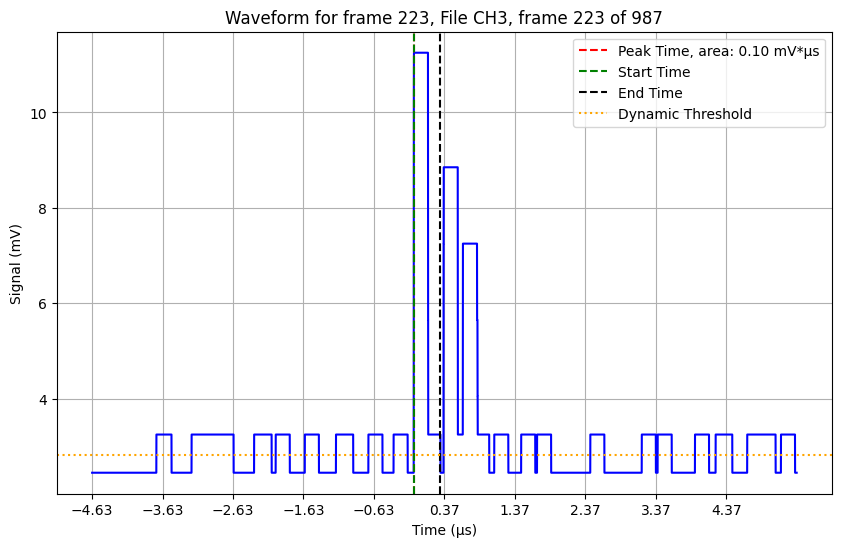

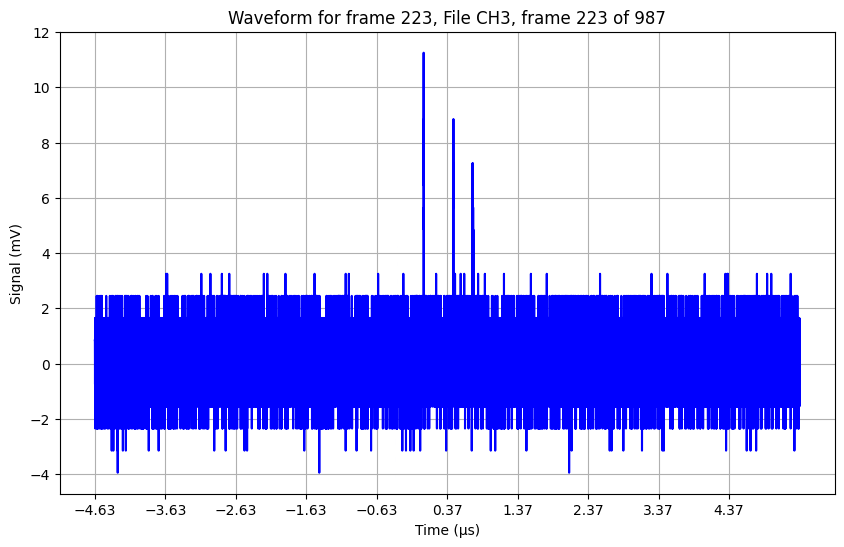

In [398]:
from RaTag.waveform.preprocessing import moving_average, subtract_pedestal
from scipy.ndimage import maximum_filter1d
i -= 1
s2_threshold = 150
t_min_s2 = -2.0
s2_fraction = 0.25
s2_min = 0.5

clips = wf.v < s2_threshold

wf_sub = subtract_pedestal(wf, n_points=200)
# wf_smooth = moving_average(wf_sub, window=1000)
v_envelope = maximum_filter1d(wf_sub.v, size=1000, axis=1)
wf_smooth = replace(wf_sub, v=v_envelope, nframes=wf_sub.nframes)

mask = wf_smooth.t > t_min_s2
t_sliced = wf_smooth.t[mask]
v_sliced = wf_smooth.v[:, mask] if wf_smooth.ff else wf_smooth.v[mask][np.newaxis, :]

# 3. Anchor to the Global Maximum
peak_idx = np.argmax(v_sliced, axis=1)
peak_heights = v_sliced[np.arange(len(v_sliced)), peak_idx]
peak_times = t_sliced[peak_idx]
    
dynamic_thresh = (peak_heights * s2_fraction)[:, np.newaxis]

# Create a boolean mask of points below threshold to the left of the peak
below_thresh = v_sliced <= dynamic_thresh
idx_2d = np.arange(v_sliced.shape[1])[np.newaxis, :]
left_mask = idx_2d <= peak_idx[:, np.newaxis]
valid_left = below_thresh & left_mask
first_below_left_rev = np.argmax(np.fliplr(valid_left), axis=1)
start_time = t_sliced[np.clip(v_sliced.shape[1] - 1 - first_below_left_rev, 0, v_sliced.shape[1] - 1)]

right_mask = idx_2d >= peak_idx[:, np.newaxis]
valid_right = below_thresh & right_mask
last_below_right = np.argmax(valid_right, axis=1)
end_time = t_sliced[np.clip(last_below_right - 1, 0, v_sliced.shape[1] - 1)]

dt = wf_sub.t[1] - wf_sub.t[0]
t_2d = wf_sub.t[np.newaxis, :]
peak_times_2d = peak_times[:, np.newaxis]

v_full = wf_sub.v
s2_mask = (t_2d >= start_time[:, np.newaxis]) & (t_2d <= end_time[:, np.newaxis])
s2_areas = np.sum(v_full * s2_mask, axis=1) * dt

plot_waveform(wf_smooth, frame=i, color='blue', title=f"Waveform for frame {i}")
plt.axvline(peak_times[i], color='red', linestyle='--', label='Peak Time, area: {:.2f} mV*µs'.format(s2_areas[i]))
plt.axvline(start_time[i], color='green', linestyle='--', label='Start Time')
plt.axvline(end_time[i], color='black', linestyle='--', label='End Time')

plt.axhline(dynamic_thresh[i], color='orange', linestyle=':', label='Dynamic Threshold')

plt.legend()
plot_waveform(wf_sub, frame=i, title=f"Waveform for frame {i}")

In [414]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter1d
from RaTag.waveform.preprocessing import moving_average, subtract_pedestal

def diagnose_find_s2_frame(wf, frame_idx: int) -> None:
    """
    Runs the S2 search logic on a single frame and plots the results 
    with explicit vertical and horizontal markers to debug boundary failures.
    """
    # 1. Base parameters & preprocessing
    s2_threshold = 150
    t_min_s2 = -2.0
    s2_fraction = 0.2
    s2_min = 0.5
    s2_max = 50.0  

    # Extract single frame for inspection if wf is 2D (FastFrame)
    is_ff = getattr(wf, 'ff', False)
    v_raw = wf.v[frame_idx, :] if is_ff else wf.v
    t_axis = wf.t

    # Check clipping
    is_clipped = np.any(v_raw >= s2_threshold)
    if is_clipped:
        print(f"Frame {frame_idx} is CLIPPED (exceeds {s2_threshold} mV).")

    # Pedestal subtraction and smoothing (envelope via maximum_filter1d)
    # Replicating pipeline steps explicitly for auditability
    pedestal = v_raw[:200].mean()
    v_sub = v_raw - pedestal
    
    # Apply maximum filter along the 1D sample axis
    v_envelope = maximum_filter1d(v_sub, size=1000)

    # Slice region of interest
    mask = t_axis > t_min_s2
    t_sliced = t_axis[mask]
    v_sliced = v_envelope[mask]

    # 2. Anchor to Global Maximum & Find Boundaries within sliced region
    peak_idx = np.argmax(v_sliced)
    peak_height = v_sliced[peak_idx]
    peak_time = t_sliced[peak_idx]
    
    dynamic_thresh = peak_height * s2_fraction
    below_thresh = v_sliced <= dynamic_thresh
    idx_1d = np.arange(len(v_sliced))

    # Left boundary search
    left_mask = idx_1d <= peak_idx
    valid_left = below_thresh & left_mask
    if np.any(valid_left):
        # Find last index on the left below threshold
        first_below_left_rev = np.argmax(np.fliplr(valid_left[np.newaxis, :]))
        start_idx = max(len(v_sliced) - 1 - first_below_left_rev, 0)
        start_time = t_sliced[start_idx]
    else:
        start_time = t_sliced[0]
        start_idx = 0

    # Right boundary search
    right_mask = idx_1d >= peak_idx
    valid_right = below_thresh & right_mask
    if np.any(valid_right):
        # Find first index on the right below threshold
        last_below_right = np.argmax(valid_right)
        end_idx = min(max(last_below_right - 1, 0), len(v_sliced) - 1)
        end_time = t_sliced[end_idx]
    else:
        end_time = t_sliced[-1]
        end_idx = len(v_sliced) - 1

    # 3. Area Integration for this frame
    dt = t_axis[1] - t_axis[0]
    s2_mask = (t_axis >= start_time) & (t_axis <= end_time)
    s2_area = np.sum(v_sub[s2_mask]) * dt

    print(f"--- Diagnostic for Frame {frame_idx} ---")
    print(f"Peak Height: {peak_height:.2f} mV at Time: {peak_time:.3f} us")
    print(f"Dynamic Threshold (25%): {dynamic_thresh:.2f} mV")
    print(f"Start Time: {start_time:.3f} us | End Time: {end_time:.3f} us")
    print(f"Integrated S2 Area: {s2_area:.3f} mV*us")
    print(f"Valid Left Found: {np.any(valid_left)} | Valid Right Found: {np.any(valid_right)}")

    # 4. Explicit Plotting to visualize failure modes
    plt.figure(figsize=(10, 6))
    plt.plot(t_axis, v_sub, color='lightgray', label='Pedestal Subtracted')
    plt.plot(t_axis, v_envelope, color='blue', label='Envelope (maximum_filter1d)')
    plt.axvline(peak_time, color='red', linestyle='--', label=f'Peak Time ({peak_time:.2f} us)')
    plt.axvline(start_time, color='green', linestyle='-', label=f'Start Time ({start_time:.2f} us)')
    plt.axvline(end_time, color='purple', linestyle='-', label=f'End Time ({end_time:.2f} us)')
    plt.axhline(dynamic_thresh, color='orange', linestyle=':', label=f'Threshold ({dynamic_thresh:.2f} mV)')
    plt.axvspan(start_time, end_time, color='pink', alpha=0.3, label='Integrated S2 Region')
    
    plt.xlim(t_min_s2, t_axis[-1])
    plt.title(f"S2 Diagnostic | Frame {frame_idx} | Area: {s2_area:.2f} mV*us")
    plt.xlabel("Time (us)")
    plt.ylabel("Signal (mV)")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

--- Diagnostic for Frame 249 ---
Peak Height: 20.16 mV at Time: 1.115 us
Dynamic Threshold (25%): 4.03 mV
Start Time: 0.021 us | End Time: 1.551 us
Integrated S2 Area: 2.921 mV*us
Valid Left Found: True | Valid Right Found: True


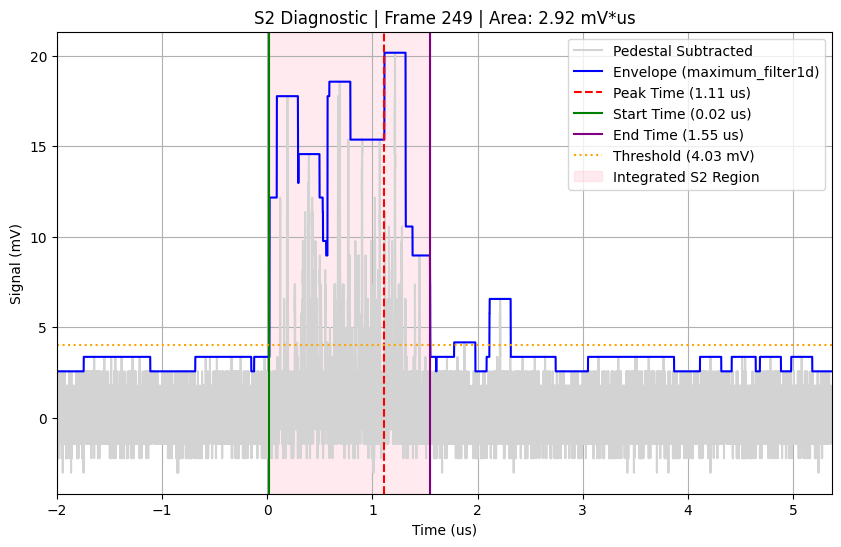

In [431]:
i += 1
diagnose_find_s2_frame(wf, frame_idx=i)

(<Axes: title={'center': 'Processed Waveform for frame 108, File CH3, frame 0 of 1'}, xlabel='Time (µs)', ylabel='Signal (mV)'>,
 np.float64(58.151604116000236))

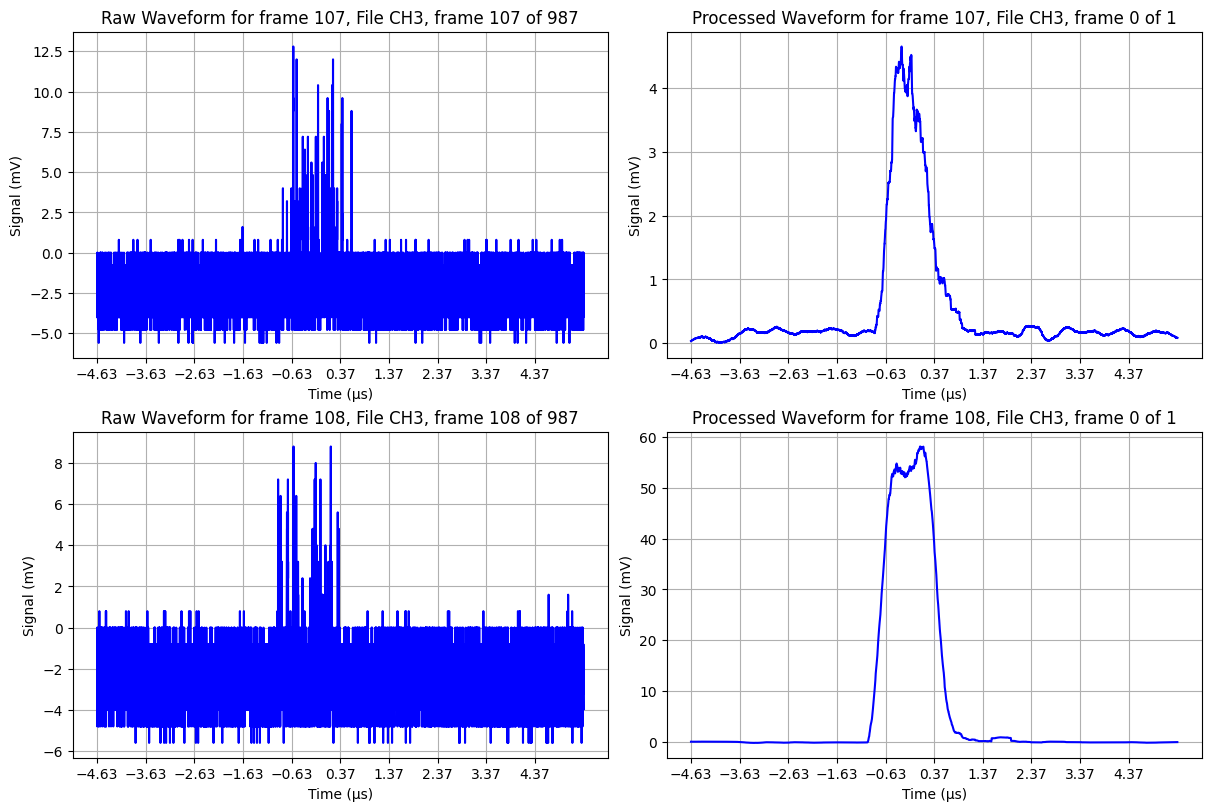

In [235]:
from RaTag.waveform.preprocessing import moving_average, subtract_pedestal
i = 107
fig, ax = plt.subplots(2, 2, figsize=(12, 8), layout='constrained')
v_mean = np.mean(wf.v[40+i:40+i+1], axis=0)
wf_mean = replace(wf, v=v_mean[np.newaxis, :], nframes=1)
wf_sub = subtract_pedestal(wf_mean, n_points=200)
wf_mean = moving_average(wf_sub, window=2000)
cumsum = np.cumsum(wf_mean.v)
plot_waveform(wf, frame=i, title=f"Raw Waveform for frame {i}", ax=ax[0, 0])
plot_waveform(wf_mean, title=f"Processed Waveform for frame {i}", ax=ax[0, 1])

i = 108
v_mean = np.mean(wf.v[40+i:40+i+1], axis=0)
wf_mean = replace(wf, v=v_mean[np.newaxis, :], nframes=1)
wf_sub = subtract_pedestal(wf_mean, n_points=200)
wf_mean = moving_average(wf_sub, window=2000)
cumsum = np.cumsum(wf_mean.v)
plot_waveform(wf, frame=i, title=f"Raw Waveform for frame {i}", ax=ax[1, 0])
plot_waveform(wf_mean, title=f"Processed Waveform for frame {i}", ax=ax[1, 1])


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

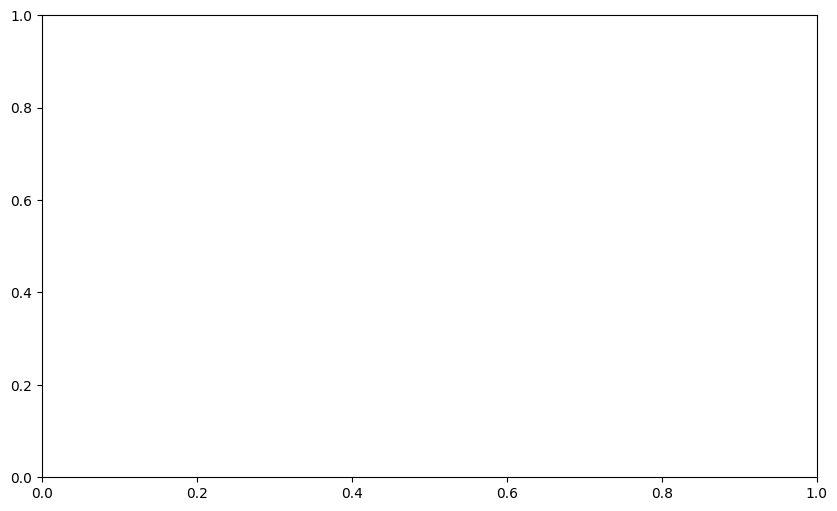

In [42]:
frame_idx += 1
wf = load_wfm(set9.source_dir / set9.filenames[0])
wf_sum = replace(wf, v=np.sum(wf.v, axis=0) if wf.ff else wf.v)
plot_waveform(wf_sum, title=f"Waveform for frame_idx {frame_idx}")
# plt.gca().set(xlim=(-3.5,-2), ylim=(-3, 10))
# plot_full_coincidence_diagnostic(wf, config=TimingConfig(), frame_idx=frame_idx)

In [145]:
from RaTag.io.file_ops import load_yaml
config = load_yaml('/Users/pabloherrero/sabat/RaTagging/configs/recoils/run32_analysis.yaml')

In [121]:
config['preparation']

{'s1_t_min': -4.0,
 's1_t_max': -2.5,
 's1_v_min': 3.0,
 's1_v_max': 15.0,
 's1_max_area': 0.15,
 's2_margin': 0.9,
 's2_threshold': 0.5,
 's2_fraction': 0.05,
 's2_min_area': 0.5,
 's2_max_area': 50,
 's2_min_width': 0.2}

# Run 37 check (dV = 1200 V)

In [ ]:
from RaTag.thgem_tpc.recoil_workflow import map_recoil_integration, find_s2, map_recoil_plots
from RaTag.io.file_ops import iter_waveforms

In [4]:
config_path_37 = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run37_analysis.yaml'

run37 = bootstrap_from_config(config_path_37)

Found 2 directories in RUN37_EL30kVcm
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0216_Anode1416 with 1 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0768_Anode_1968 with 1 waveforms.
  → Bootstrapped 2 PMT Sets and 2 Alpha Sets. (Multi-Isotope: True)


In [9]:
run37 = map_recoil_integration(run37, config=TimingConfig(s2_max_area=500), force=True)


INTEGRATING S2 RECOILS: RUN_37
  Iterating FieldScan_Gate0216_Anode1416: 10/10 (100.0%) | ETA: 00:00   
  FieldScan_Gate0216_Anode1416: 4554/9870 events (46.1%)
  ✓ All 4554 accepted events have valid UIDs.
  ✓ FieldScan_Gate0216_Anode1416: Computed 'n_areas_recoil' and stored metadata
  Iterating FieldScan_Gate0768_Anode_1968: 10/10 (100.0%) | ETA: 00:00   
  FieldScan_Gate0768_Anode_1968: 4555/9870 events (46.1%)
  ✓ All 4555 accepted events have valid UIDs.
  ✓ FieldScan_Gate0768_Anode_1968: Computed 'n_areas_recoil' and stored metadata


In [14]:
map_recoil_plots(run37, config=FitConfig(bin_cuts=(-1, 10)), force=True)


GENERATING RECOIL S2 AREAS QA PLOTS: RUN_37
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN37_EL30kVcm/s2_areas/FieldScan_Gate0216_Anode1416_s2_areas.npz
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN37_EL30kVcm/s2_areas/FieldScan_Gate0768_Anode_1968_s2_areas.npz
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN37_EL30kVcm/plots/s2_areas/RUN_37_histograms.png


Run state:
  root_directory = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN37_EL30kVcm
  run_id = RUN_37
  el_field = 30000.0
  multiiso = True
  target_isotope = multi
  pressure = 1.0
  temperature = 297.0
  sampling_rate = 5.0e9
  el_gap = 0.04
  drift_gap = 0.48
  sets = <2 SetPmt objects>
  alpha_sets = <2 SetAlpha objects>
  width_s2 = 1.1
  t_s1 = 0.0
  recoil_energy = 96.8
  W_value = 22.0
  E_gamma_xray = 12300.0

  Missing:
    gas_density, g_S2, alpha_calibration, isotope_ranges

In [13]:
set0 = run37.sets[0]
for wf in iter_waveforms(set0, max_files=None, show_progress=True):
    result_dict = find_s2(wf, config=TimingConfig())

  Iterating FieldScan_Gate0216_Anode1416: 10/10 (100.0%) | ETA: 00:00   


# Troubleshooting timing data

In [42]:
path_time = '/Volumes/KINGSTON/RaTag_data/processed/RUN37_EL30kVcm/timing/FieldScan_Gate0156_Anode1356_timing.npz'
file = np.load(path_time)
starts = file['t_s2_start']
ends = file['t_s2_end']
peaks = file['t_s2_peak']
uids = file['uids']

In [35]:
path_areas = '/Volumes/KINGSTON/RaTag_data/processed/RUN38_EL25kVcm/s2_areas/FieldScan_Gate0768_Anode1768_s2_areas.npz'
file_areas = np.load(path_areas)
s2_areas = file_areas['s2_areas']
uids2 = file_areas['uids']


In [43]:
len(starts), len(ends), len(peaks)

(87246, 87246, 87246)

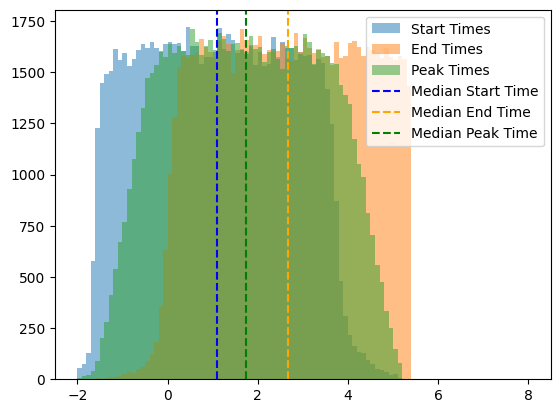

In [44]:
plt.hist(starts, bins=100, range=(-2, 8), alpha=0.5, label='Start Times');
plt.hist(ends, bins=100, range=(-2, 8), alpha=0.5, label='End Times');
plt.hist(peaks, bins=100, range=(-2, 8), alpha=0.5, label='Peak Times');
plt.axvline(np.median(starts), color='blue', linestyle='--', label='Median Start Time')
plt.axvline(np.median(ends), color='orange', linestyle='--', label='Median End Time')
plt.axvline(np.median(peaks), color='green', linestyle='--', label='Median Peak Time')
plt.legend()

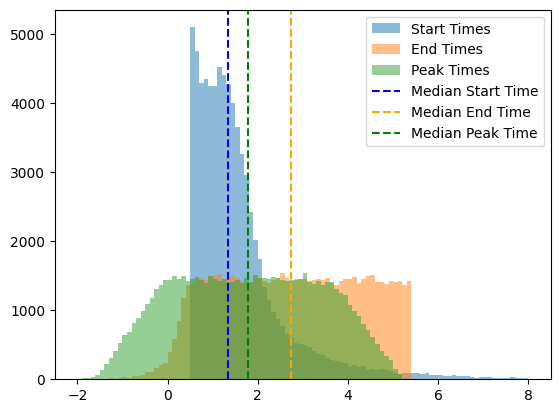

In [ ]:
plt.hist(starts, bins=100, range=(-2, 8), alpha=0.5, label='Start Times');
plt.hist(ends, bins=100, range=(-2, 8), alpha=0.5, label='End Times');
plt.hist(peaks, bins=100, range=(-2, 8), alpha=0.5, label='Peak Times');
plt.axvline(np.median(starts), color='blue', linestyle='--', label='Median Start Time')
plt.axvline(np.median(ends), color='orange', linestyle='--', label='Median End Time')
plt.axvline(np.median(peaks), color='green', linestyle='--', label='Median Peak Time')
plt.legend()

# Diagnosis full processing + alpha

In [4]:
from RaTag.core.dataIO import load_wfm, load_alpha
from RaTag.alphas.alphas_calibration import map_alpha_calibrations
from RaTag.alphas.alphas_workflow import map_alpha_events
from RaTag.io.file_ops import extract_single_frame
from RaTag.thgem_tpc.diagnostics import plot_full_coincidence_diagnostic
    

In [5]:
run = map_alpha_events(run, force=False)

run = map_alpha_calibrations(run, force=False)


RECONSTRUCTING ALPHA ENERGIES: RUN_43
Force flag: False
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0188_Anode1188'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0288_Anode1288'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0480_Anode1480'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0576_Anode1576'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0672_Anode1672'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0768_Anode1768'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0864_Anode1864'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0960_Anode1960'

CALIBRATING ALPHA ENERGIES: RUN_43
  📂 Cache Hit: Loaded metadata for 'calib_a in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'calib_a in FieldScan

In [149]:
set_index = 8

file_idx = 0 
frame_idx = 0 


set_pmt = run.sets[set_index]
set_alpha = run.alpha_sets[set_index]


In [90]:

pmt_filename = set_pmt.filenames[file_idx]
pmt_path = set_pmt.source_dir / pmt_filename


# alpha_filename = pmt_filename.replace('_CH3.wfm', '_CH4.wfm')
# alpha_path = set_alpha.source_dir / alpha_filename

# 3. Load the full FastFrame files
wf_pmt_full = load_wfm(pmt_path)
# wf_alpha_full = load_alpha(alpha_path)


[Text(0.5, 0, 'Time (µs)')]

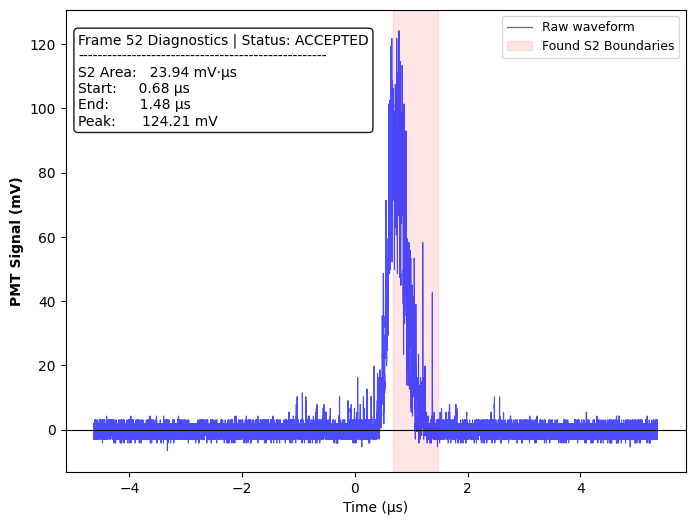

In [156]:
frame_idx = 52
# 4. Extract the synchronized single frames
wf_pmt = extract_single_frame(wf_pmt_full, frame_idx)
# wf_alpha = extract_single_frame(wf_alpha_full, frame_idx)

# 5. Inject into the pure physics plotter
fig = plot_full_coincidence_diagnostic(wf_pmt, wf_alpha, config=TimingConfig())
plt.gca().set(xlabel='Time (µs)')

# Compare different S2 integration windows

In [42]:
from RaTag.thgem_tpc.recoil_workflow import find_s2, resolve_set_recoils
from RaTag.io import file_ops

In [12]:
set1 = run.sets[1]
set8 = run.sets[8]

In [43]:
integ_interval = 1.5
t_delay_step = 0.2
current_set = set1
max_files = None
s2_areas_dict2 = {}
for t_delay in np.arange(0.0, 0.6, t_delay_step):
    print(f"Testing t_start_delay = {t_delay:.2f} µs")

    total_frames = 0
    accepted_frames = 0
    accum_areas, accum_uids, accum_starts, accum_ends, accum_peaks = [], [], [], [], []

    for wf in file_ops.iter_waveforms(current_set, max_files=max_files, show_progress=True):
        result_dict = find_s2(wf, config=TimingConfig(), t_start_delay = t_delay, integ_interval=integ_interval)
        total_frames += wf.nframes
        accepted_frames += result_dict['n_accepted']
        if result_dict['n_accepted'] > 0:
            accum_areas.append(result_dict['s2_areas'])
            accum_uids.append(result_dict['uids'])
            accum_starts.append(result_dict['start_times'])
            accum_ends.append(result_dict['end_times'])
            accum_peaks.append(result_dict['peak_times'])

    retention = float((accepted_frames / total_frames * 100) if total_frames > 0 else 0.0)
    print(f"  {current_set.source_dir.name}: {accepted_frames}/{total_frames} events ({retention:.1f}%)")
        
    area_arrays = {}
    if len(result_dict['s2_areas']) > 0:
        start_concat = np.concatenate(accum_starts)
        end_concat = np.concatenate(accum_ends)
        uids_concat = np.concatenate(accum_uids)

        area_arrays = {
            "uids": uids_concat,
            "s2_areas": np.concatenate(accum_areas),
            "t_s2_start": start_concat,
            "t_s2_end": end_concat,
            "t_s2_peak": np.concatenate(accum_peaks)
        }
    file_ops.save_npz_arrays(current_set, f'area_{t_delay:.2f}_free_end', area_arrays)
    s2_areas_dict2[t_delay] = area_arrays



Testing t_start_delay = 0.00 µs
  Iterating FieldScan_Gate0188_Anode1188: 200/200 (100.0%) | ETA: 00:00   
  FieldScan_Gate0188_Anode1188: 51731/197400 events (26.2%)
Testing t_start_delay = 0.20 µs
  Iterating FieldScan_Gate0188_Anode1188: 200/200 (100.0%) | ETA: 00:00   
  FieldScan_Gate0188_Anode1188: 45872/197400 events (23.2%)
Testing t_start_delay = 0.40 µs
  Iterating FieldScan_Gate0188_Anode1188: 200/200 (100.0%) | ETA: 00:00   
  FieldScan_Gate0188_Anode1188: 41004/197400 events (20.8%)


In [36]:
area_free_end_path = '/Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas_halfpeak/FieldScan_Gate0188_Anode1188_s2_areas.npz'
area_free_end = np.load(area_free_end_path)['s2_areas']

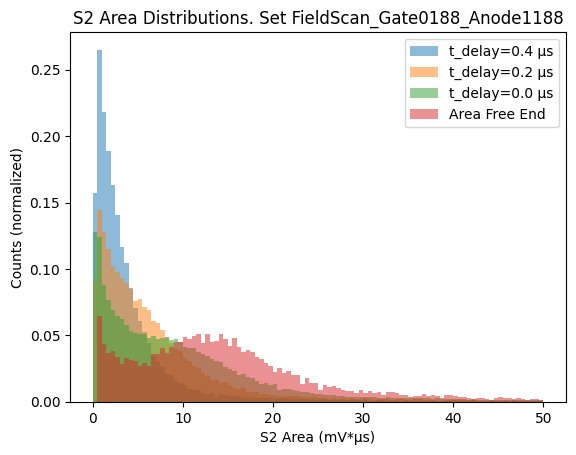

In [ ]:
plt.hist(s2_areas_dict2[0.4]['s2_areas'], bins=100, range=(0, 50), density=True, alpha=0.5, label='t_delay=0.4 µs');
plt.hist(s2_areas_dict2[0.2]['s2_areas'], bins=100, range=(0, 50), density=True, alpha=0.5, label='t_delay=0.2 µs');
plt.hist(s2_areas_dict2[0.0]['s2_areas'], bins=100, range=(0, 50), density=True, alpha=0.5, label='t_delay=0.0 µs');
# plt.hist(area_free_end, bins=100, range=(0, 50), density=True,  alpha=0.5, label='Area Free End');
plt.gca().set(xlabel='S2 Area (mV*µs)', ylabel='Counts (normalized)', title=f'S2 Area Distributions. Set {current_set.name}')
plt.legend();



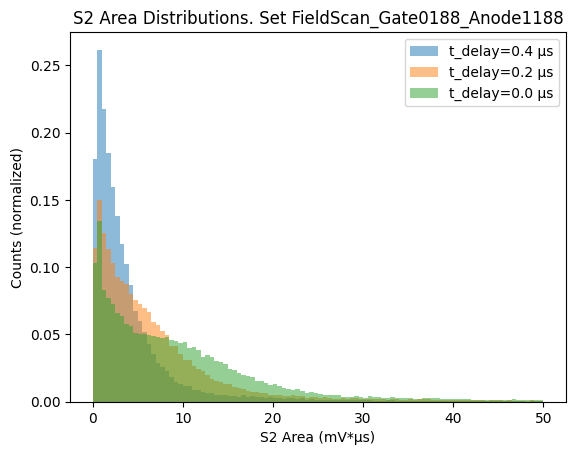

In [44]:
plt.hist(s2_areas_dict[0.4]['s2_areas'], bins=100, range=(0, 50), density=True, alpha=0.5, label='t_delay=0.4 µs');
plt.hist(s2_areas_dict[0.2]['s2_areas'], bins=100, range=(0, 50), density=True, alpha=0.5, label='t_delay=0.2 µs');
plt.hist(s2_areas_dict[0.0]['s2_areas'], bins=100, range=(0, 50), density=True, alpha=0.5, label='t_delay=0.0 µs');
# plt.hist(area_free_end, bins=100, range=(0, 50), density=True,  alpha=0.5, label='Area Free End');
plt.gca().set(xlabel='S2 Area (mV*µs)', ylabel='Counts (normalized)', title=f'S2 Area Distributions. Set {current_set.name}')
plt.legend();



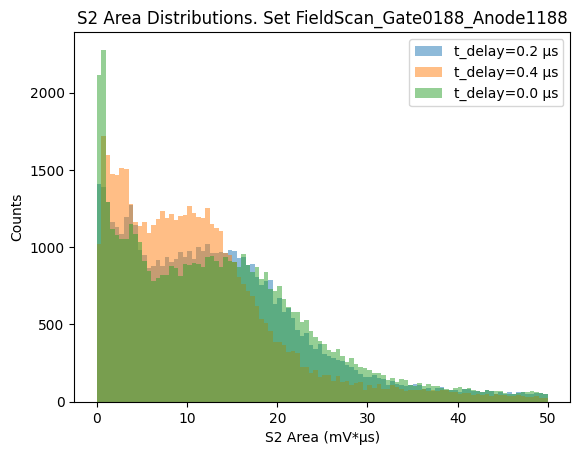

In [ ]:
plt.hist(s2_areas_dict[0.0]['s2_areas'], bins=100, range=(0, 50), alpha=0.5, label='t_delay=0.0 µs');
plt.hist(s2_areas_dict[0.2]['s2_areas'], bins=100, range=(0, 50), alpha=0.5, label='t_delay=0.2 µs');
plt.hist(s2_areas_dict[0.4]['s2_areas'], bins=100, range=(0, 50), alpha=0.5, label='t_delay=0.4 µs');
plt.gca().set(xlabel='S2 Area (mV*µs)', ylabel='Counts', title=f'S2 Area Distributions. Set {current_set.name}')
plt.legend();



### Plot waveforms with their integration interval for illustration

In [27]:
from RaTag.core.dataIO import load_wfm, load_alpha
from RaTag.io.file_ops import extract_single_frame
from RaTag.thgem_tpc.diagnostics import plot_full_coincidence_diagnostic
    

In [28]:
file_idx = 0 
frame_idx = 0 
pmt_filename = current_set.filenames[file_idx]
pmt_path = current_set.source_dir / pmt_filename

wf_pmt_full = load_wfm(pmt_path)

[Text(0.5, 0, 'Time (µs)')]

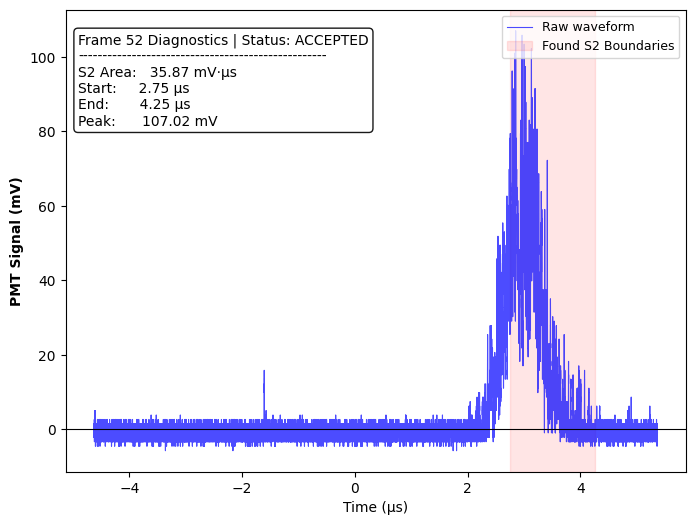

In [29]:
frame_idx = 52
# 4. Extract the synchronized single frames
wf_pmt = extract_single_frame(wf_pmt_full, frame_idx)
# wf_alpha = extract_single_frame(wf_alpha_full, frame_idx)

# 5. Inject into the pure physics plotter
fig = plot_full_coincidence_diagnostic(wf_pmt, None, config=TimingConfig())
plt.gca().set(xlabel='Time (µs)')